# Thesis Project

## Student: Tairbek Akhayev 551094

# EEG Classification with KAN and Baseline Models


## 1. Setup and Imports


In [22]:
# 1) Imports + config + basics
import os
import warnings
import yaml
import numpy as np
import torch

# графики оставим в ноутбуке; функции рисования — позже из code/visuals.py
import matplotlib.pyplot as plt

# подавим болтливость MNE
warnings.filterwarnings("ignore", category=UserWarning, module="mne")

# --- наш пайплайн из code/ ---
from kanlib.data_loading  import read_edf
from kanlib.preprocess import bandpass_notch
from kanlib.windowing import make_forecast_pairs
from kanlib.splits import split_by_file, loso_split
from kanlib.metrics import mae, rmse, smape
from kanlib.train import ForecastDataset, compute_channel_stats, train_loop

# модели подключим по мере необходимости
from kanlib.models.lstm import LSTMLite
from kanlib.models.kan import KANRegressor
# при желании: из models.linridge / tcn / xgb

# --- config ---
import yaml

CONFIG_PATH = "config.yaml"

try:
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)
except UnicodeDecodeError:
    # На случай BOM или странной кодировки пробуем ещё один вариант
    with open(CONFIG_PATH, "r", encoding="utf-8-sig") as f:
        cfg = yaml.safe_load(f)


# --- устройство и сиды ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(cfg.get("random_seed", 42))
torch.manual_seed(cfg.get("random_seed", 42))

print(f"Device: {device}")
print("Config loaded.")


Device: cpu
Config loaded.


## 2. Data Paths and Environment Setup


In [23]:
import os
import platform

# Читаем пути из config.yaml (если указаны)
data_dir = cfg.get("data", {}).get("raw_dir", None)
out_dir  = cfg.get("data", {}).get("out_dir", None)

if data_dir is None or out_dir is None:
    if platform.system() == "Windows":  # Azure Lab Services обычно под Windows
        data_dir = r"C:\Users\utente\Desktop\ThesisKAN\kanproject\dataverse_files"
        out_dir  = r"D:\thesis_data\processed"
    else:  # macOS/Linux (твой локальный ноут)
        data_dir = "/Users/tairakhayev/Desktop/ThesisProject/dataverse_files"
        out_dir  = os.path.abspath("./processed")

# записываем в переменные окружения (для совместимости с твоим старым кодом)
os.environ["THESIS_DATA_DIR"] = data_dir
os.environ["THESIS_OUT_DIR"]  = out_dir

print(f"Data dir: {data_dir}")
print(f"Out dir:  {out_dir}")


Data dir: /Users/tairakhayev/Desktop/ThesisProject/dataverse_files
Out dir:  ./processed


## 3. Data Discovery


In [24]:
# ==== Data discovery (recursive glob from config.yaml) ====
import os
from glob import glob

DATA_DIR = cfg["data"]["raw_dir"]
assert DATA_DIR and os.path.isdir(DATA_DIR), f"DATA_DIR not found: {DATA_DIR}"

edf_lower = glob(os.path.join(DATA_DIR, "**", "*.edf"), recursive=True)
edf_upper = glob(os.path.join(DATA_DIR, "**", "*.EDF"), recursive=True)
all_files = sorted(set(edf_lower + edf_upper))

print("DATA_DIR:", DATA_DIR)
print(f"Total EDF files found (recursive): {len(all_files)}")
for i, fp in enumerate(all_files[:5]):
    print(f"[{i+1}] {fp}")



DATA_DIR: /Users/tairakhayev/Desktop/ThesisProject/dataverse_files
Total EDF files found (recursive): 28
[1] /Users/tairakhayev/Desktop/ThesisProject/dataverse_files/h01.edf
[2] /Users/tairakhayev/Desktop/ThesisProject/dataverse_files/h02.edf
[3] /Users/tairakhayev/Desktop/ThesisProject/dataverse_files/h03.edf
[4] /Users/tairakhayev/Desktop/ThesisProject/dataverse_files/h04.edf
[5] /Users/tairakhayev/Desktop/ThesisProject/dataverse_files/h05.edf


## 4. Channel Name Inspection & Mapping
### 1) Define the list of desired EEG channels from config.yaml
### 2) Normalize channel names (case-insensitive, ignore spaces/underscores)
### 3) Build a mapping from raw EDF channel names → desired config names
### 4) Report which desired channels are found or missing in sample EDF files

In [25]:
# ==== Inspect channel names + check desired channels from config ====
import os
import mne

desired = cfg["data"]["channels"]  # the 9 target channels from config.yaml

def normalize_names(names):
    # normalize to uppercase, remove spaces and underscores for robust matching
    return {n.upper().replace(" ", "").replace("_", ""): n for n in names}

def find_channel_mapping(file_channels, desired_channels):
    """
    Returns:
      - mapping: dict {raw_channel_name -> desired_config_name}
      - missing: list of desired channels that are not found in this file
    Matching is case/space/underscore insensitive.
    """
    raw_norm = normalize_names(file_channels)          
    want_norm = {ch.upper().replace(" ", "").replace("_", ""): ch for ch in desired_channels}
    mapping = {}
    for k_norm, want_name in want_norm.items():
        if k_norm in raw_norm:
            mapping[ raw_norm[k_norm] ] = want_name
    missing = [want_name for k_norm, want_name in want_norm.items() if k_norm not in raw_norm]
    return mapping, missing

sample_files = all_files[:4]

for fp in sample_files:
    try:
        raw_hdr = mne.io.read_raw_edf(fp, preload=False, verbose=False)
        ch_names = raw_hdr.ch_names
        preview = ch_names[:10]
        suffix = " ..." if len(ch_names) > 10 else ""
        mapping, missing = find_channel_mapping(ch_names, desired)

        print(f"\n{os.path.basename(fp)} -> {preview}{suffix} (total {len(ch_names)} channels)")
        if mapping:
            found_pretty = [f"{src}→{dst}" if src != dst else dst for src, dst in mapping.items()]
            print("  ✓ Found (mapped):", ", ".join(found_pretty))
        if missing:
            print("  ✗ Missing:", ", ".join(missing))
        else:
            print("  ✓ All desired channels present.")
    except Exception as e:
        print(f"\nError reading {os.path.basename(fp)}: {e}")



h01.edf -> ['Fp2', 'F8', 'T4', 'T6', 'O2', 'Fp1', 'F7', 'T3', 'T5', 'O1'] ... (total 19 channels)
  ✓ Found (mapped): Fp1, Fp2, Fz, C3, C4, Pz, O1, O2, Cz
  ✓ All desired channels present.

h02.edf -> ['Fp2', 'F8', 'T4', 'T6', 'O2', 'Fp1', 'F7', 'T3', 'T5', 'O1'] ... (total 19 channels)
  ✓ Found (mapped): Fp1, Fp2, Fz, C3, C4, Pz, O1, O2, Cz
  ✓ All desired channels present.

h03.edf -> ['Fp2', 'F8', 'T4', 'T6', 'O2', 'Fp1', 'F7', 'T3', 'T5', 'O1'] ... (total 19 channels)
  ✓ Found (mapped): Fp1, Fp2, Fz, C3, C4, Pz, O1, O2, Cz
  ✓ All desired channels present.

h04.edf -> ['Fp2', 'F8', 'T4', 'T6', 'O2', 'Fp1', 'F7', 'T3', 'T5', 'O1'] ... (total 19 channels)
  ✓ Found (mapped): Fp1, Fp2, Fz, C3, C4, Pz, O1, O2, Cz
  ✓ All desired channels present.


## 5. Channel Presence Validation
### 1) Loop through all EDF files and check if each desired channel is present
### 2) Collect a report of files where one or more desired channels are missing
### 3) Print a summary: either all files are valid or show the first few problematic cases


In [26]:
# ==== Validate that all desired channels are present in each file ====
import os, mne

desired = cfg["data"]["channels"]
missing_report = []

for fp in all_files:
    try:
        raw_hdr = mne.io.read_raw_edf(fp, preload=False, verbose=False)
        ch_names = raw_hdr.ch_names
        present = set(ch_names)
        missing = [ch for ch in desired if ch not in present]
        if missing:
            missing_report.append((os.path.basename(fp), missing))
    except Exception as e:
        missing_report.append((os.path.basename(fp), [f"read_error: {e}"]))

if not missing_report:
    print("✓ All desired channels present in all files.")
else:
    print(f"⚠ Files with missing desired channels: {len(missing_report)}")
    for fname, miss in missing_report[:10]:
        print(f" - {fname}: missing {miss}")
    if len(missing_report) > 10:
        print(" ... (truncated)")


✓ All desired channels present in all files.


## 6. Visualize Selected EEG Channels
### 1) Use the standard 10-20 electrode montage from MNE
### 2) Map the desired channels (from config) to montage positions
### 3) Handle possible alternative labels (e.g., T3→T7, T4→T8)
### 4) Plot electrode positions for selected channels (for thesis figures)
### 5) Print channel coordinates (useful for appendix or supplementary material)


<Figure size 600x600 with 0 Axes>

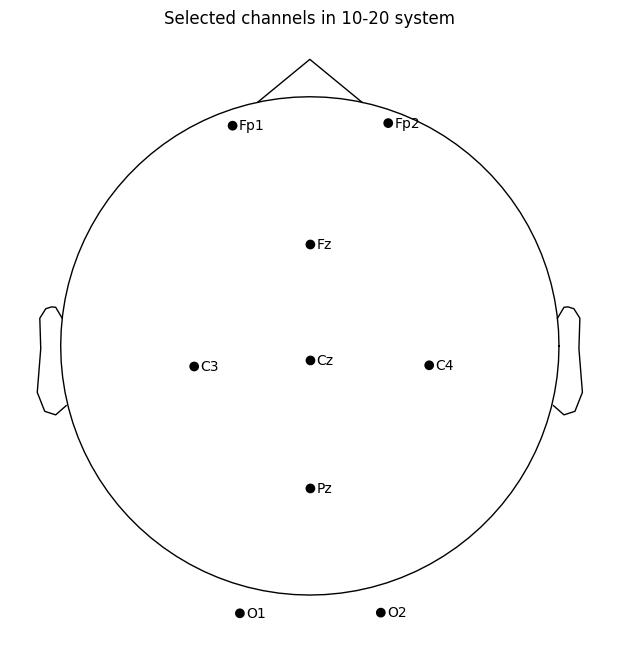

Fp1: [-0.0294367  0.0839171 -0.00699  ]
Fp2: [ 0.0298723  0.0848959 -0.00708  ]
Fz: [0.0003122 0.058512  0.066462 ]
C3: [-0.0653581 -0.0116317  0.064358 ]
C4: [ 0.0671179 -0.0109003  0.06358  ]
Pz: [ 0.0003247 -0.081115   0.082615 ]
O1: [-0.0294134 -0.112449   0.008839 ]
O2: [ 0.0298426 -0.112156   0.0088   ]
Cz: [ 0.0004009 -0.009167   0.100244 ]


In [27]:
# ==== Optional: visualize selected channels (for thesis figures) ====
import mne
import matplotlib.pyplot as plt

def plot_selected_channels(selected_channels):
    """
    Рисует расположение выбранных каналов в системе 10-20.
    """
    montage = mne.channels.make_standard_montage("standard_1020")
    ch_pos_all = montage.get_positions()["ch_pos"]

    # fallback для альтернативных имён (если вдруг встретятся)
    viz_map = {"T3": "T7", "T4": "T8"}

    viz_channels = []
    for ch in selected_channels:
        base = viz_map.get(ch, ch)
        # пробуем разные варианты регистра
        candidates = [base, base.capitalize(), base.upper()]
        vch = next((c for c in candidates if c in ch_pos_all), None)
        viz_channels.append(vch)

    sel_pos = {ch: ch_pos_all[vch] for ch, vch in zip(selected_channels, viz_channels) if vch is not None}
    missing = [ch for ch, vch in zip(selected_channels, viz_channels) if vch is None]
    if missing:
        print("⚠️ Missing in standard_1020:", missing)

    sel_montage = mne.channels.make_dig_montage(ch_pos=sel_pos, coord_frame="head")
    fig = plt.figure(figsize=(6, 6))
    mne.viz.plot_montage(sel_montage, show_names=True, sphere=0.1, show=False)
    plt.title("Selected channels in 10-20 system")
    plt.show()

    # координаты (если пригодятся для приложения)
    for ch, pos in sel_pos.items():
        print(f"{ch}: {pos}")

# вызов из конфигурации (без хардкода)
plot_selected_channels(cfg["data"]["channels"])


## 7. Build Forecast Pairs (Diagnostics; No Normalization Yet)
### 1) Read EDF files, apply bandpass + notch filtering, and resample to fs_target
### 2) Slice rolling windows: input X with length L, forecast target Y with horizon H (stride = cfg)
### 3) Support both target modes: "uni" (single target channel) and "multi" (all channels)
### 4) Record detailed diagnostics (too short files / zero pairs / read errors)
### 5) Save raw numpy arrays (X_raw, Y_raw, file_ids, channels) for downstream steps


In [78]:
# === Build forecast pairs (with diagnostics; no normalization) ===
import os
import numpy as np
from kanlib.data_loading import read_edf
from kanlib.preprocess import bandpass_notch
from kanlib.windowing import make_forecast_pairs

save_dir = cfg["data"]["out_dir"]
os.makedirs(save_dir, exist_ok=True)

pick_channels = cfg["data"]["channels"]
fs_target     = cfg["data"]["fs_target"]
bp_lo, bp_hi  = cfg["data"]["bandpass"]
notches       = tuple(cfg["data"]["notch"])

L       = cfg["task"]["L"]
H       = cfg["task"]["H"]
stride  = cfg["task"]["stride"]
tmode   = cfg["task"]["target_mode"]   # "uni" | "multi"
tch_name = cfg["task"]["target_channel"]

# индекс целевого канала для uni
if tmode == "uni":
    try:
        t_ch = pick_channels.index(tch_name)
    except ValueError:
        raise ValueError(f"target_channel '{tch_name}' not in data.channels {pick_channels}")
else:
    t_ch = 0  # не используется

X_list, Y_list, file_ids = [], [], []

diag = {
    "ok_files": 0,
    "short_files": [],       # T < L+H
    "zero_pairs": [],        # формально достаточно, но из-за stride получилось 0
    "errors": [],            # исключения
    "samples": []            # (fname, T, fs, n_pairs)
}

def infer_ids(filepath: str):
    base = os.path.basename(filepath)
    stem = os.path.splitext(base)[0]
    return stem, stem

for i, fp in enumerate(all_files, 1):
    fname = os.path.basename(fp)
    try:
        arr, fs = read_edf(fp, pick_channels=pick_channels, fs_target=fs_target)  # [C,T]
        arr = bandpass_notch(arr.astype(np.float64, copy=False), fs=fs, band=(bp_lo, bp_hi), notch=notches)     # [C,T]
        C, T = arr.shape

        if T < (L + H):
            diag["short_files"].append((fname, T, fs))
            if i % 5 == 0 or i == len(all_files):
                print(f"[{i}/{len(all_files)}] {fname} -> TOO SHORT (T={T} < L+H={L+H})")
            continue

        pairs = make_forecast_pairs(arr, L=L, H=H, stride=stride, target_mode=tmode, target_ch=t_ch)
        n_pairs = len(pairs)

        if n_pairs == 0:
            diag["zero_pairs"].append((fname, T, fs, L, H, stride))
            if i % 5 == 0 or i == len(all_files):
                print(f"[{i}/{len(all_files)}] {fname} -> 0 pairs (T={T}, L={L}, H={H}, stride={stride})")
            continue

        Xi = [p[0] for p in pairs]
        Yi = [p[1] for p in pairs]
        X_list.extend(Xi)
        Y_list.extend(Yi)

        fid, sid = infer_ids(fp)
        file_ids.extend([fid] * n_pairs)

        diag["ok_files"] += 1
        diag["samples"].append((fname, T, fs, n_pairs))
        if i % 5 == 0 or i == len(all_files):
            print(f"[{i}/{len(all_files)}] {fname} -> +{n_pairs} pairs (T={T}, fs={fs})")

    except Exception as e:
        diag["errors"].append((fname, str(e)))
        print(f"[WARN] skip {fname}: {e}")

if len(X_list) == 0:
    print("\n=== DIAGNOSTICS ===")
    print(f"OK files: {diag['ok_files']}")
    print(f"Too short (T < L+H={L+H}): {len(diag['short_files'])}")
    for r in diag["short_files"][:5]:
        print("  -", r)
    print(f"Zero pairs (check stride/L/H): {len(diag['zero_pairs'])}")
    for r in diag["zero_pairs"][:5]:
        print("  -", r)
    print(f"Errors while reading/filtering: {len(diag['errors'])}")
    for r in diag["errors"][:3]:
        print("  -", r)
    raise RuntimeError("No forecast pairs produced. Consider decreasing L or H, or using smaller stride.")

# Конвертируем в массивы (без нормализации)
X = np.stack(X_list).astype(np.float32)                 # [N, C, L]
Y = np.stack(Y_list).astype(np.float32)                 # [N, H] или [N, C, H]
file_ids = np.array(file_ids, dtype=object)             # [N]

C = len(pick_channels)
assert X.ndim == 3 and X.shape[1] == C and X.shape[2] == L, f"Unexpected X shape: {X.shape}"
if tmode == "uni":
    assert Y.ndim == 2 and Y.shape[1] == H, f"Unexpected Y shape for uni: {Y.shape}"
else:
    assert Y.ndim == 3 and Y.shape[1] == C and Y.shape[2] == H, f"Unexpected Y shape for multi: {Y.shape}"

np.save(os.path.join(save_dir, "X_raw.npy"), X)
np.save(os.path.join(save_dir, "Y_raw.npy"), Y)
np.save(os.path.join(save_dir, "file_ids.npy"), file_ids)
np.save(os.path.join(save_dir, "channels.npy"), np.array(pick_channels, dtype=object))

print("\nSaved to:", save_dir)
print("X_raw:", X.shape, X.dtype, "| Y_raw:", Y.shape, Y.dtype)
print("Unique files in pairs:", len(np.unique(file_ids)))
print("Pairs per first 3 files:", {fid: (file_ids == fid).sum() for fid in np.unique(file_ids)[:3]})


KeyError: 'target_channel'

## 8. Load Raw Pairs → Group Split by File → Train Stats → Build Loaders
### 1) Load previously saved artifacts (X_raw, Y_raw, file_ids, channels)
### 2) Perform a group-aware split by file IDs (train/val/test per config ratios)
### 3) Compute train-only per-channel mean/std for normalization
### 4) Build ForecastDataset objects (X normalized; Y normalized if norm_y=True)
### 5) Create DataLoaders for train/val/test


In [29]:
# ==== Load raw pairs, group-split by file, compute train stats, build loaders ====
import os
import numpy as np

from kanlib.splits import split_by_file
from kanlib.train import ForecastDataset, compute_channel_stats

save_dir = cfg["data"]["out_dir"]
assert os.path.isdir(save_dir), f"Out dir not found: {save_dir}"

# файлы, которые мы сохраняли на предыдущем шаге
X_path        = os.path.join(save_dir, "X_raw.npy")
Y_path        = os.path.join(save_dir, "Y_raw.npy")
file_ids_path = os.path.join(save_dir, "file_ids.npy")
channels_path = os.path.join(save_dir, "channels.npy")

for p in [X_path, Y_path, file_ids_path, channels_path]:
    assert os.path.isfile(p), f"Missing artifact: {p}"

X = np.load(X_path)               # [N, C, L], float32
Y = np.load(Y_path)               # [N, H] or [N, C, H], float32
file_ids = np.load(file_ids_path, allow_pickle=True)  # [N], object
channels = np.load(channels_path, allow_pickle=True).tolist()

C, L = X.shape[1], X.shape[2]
tmode = cfg["task"]["target_mode"]
H = Y.shape[1] if tmode == "uni" else Y.shape[2]

# --- сплит по файлам (60/20/20 по config) ---
ratios = tuple(cfg["split"]["ratios"])
train_files, val_files, test_files = split_by_file(file_ids, ratios=ratios, seed=cfg.get("random_seed", 42))

train_mask = np.isin(file_ids, list(train_files))
val_mask   = np.isin(file_ids, list(val_files))
test_mask  = np.isin(file_ids, list(test_files))

X_train, Y_train = X[train_mask], Y[train_mask]
X_val,   Y_val   = X[val_mask],   Y[val_mask]
X_test,  Y_test  = X[test_mask],  Y[test_mask]

assert len(X_train) and len(X_val) and len(X_test), "Empty split — check ratios or file_ids."

# --- считаем ТОЛЬКО ПО TRAIN пер-канальные mean/std ---
train_mean, train_std = compute_channel_stats(list(X_train))  # shapes: [C], [C]

# индекс целевого канала для режима "uni"
if tmode == "uni":
    target_ch_name = cfg["task"]["target_channel"]
    try:
        target_ch_idx = channels.index(target_ch_name)
    except ValueError:
        raise ValueError(f"target_channel {target_ch_name} not found in channels {channels}")
else:
    target_ch_idx = 0  # не используется

# --- собираем датасеты (нормализация внутри ForecastDataset по train_mean/std) ---
train_ds = ForecastDataset(X_train, Y_train, mean=train_mean, std=train_std,
                           target_mode=tmode, target_ch_idx=target_ch_idx, norm_y=True)
val_ds   = ForecastDataset(X_val,   Y_val,   mean=train_mean, std=train_std,
                           target_mode=tmode, target_ch_idx=target_ch_idx, norm_y=True)
test_ds  = ForecastDataset(X_test,  Y_test,  mean=train_mean, std=train_std,
                           target_mode=tmode, target_ch_idx=target_ch_idx, norm_y=True)

from torch.utils.data import DataLoader
bs = int(cfg["train"]["batch_size"])
use_cuda = (device.type == "cuda")
num_workers = 6 if use_cuda else 0

def make_loader(ds, shuffle: bool):
    kwargs = dict(batch_size=bs, shuffle=shuffle, drop_last=False)
    if num_workers > 0:
        # мультипроцессный режим (GPU/сервер)
        kwargs.update(
            num_workers=num_workers,
            pin_memory=True,                 # только при CUDA имеет смысл
            persistent_workers=True,
            prefetch_factor=4,
        )
    else:
        # однопроцессный режим (CPU/mac) — НИЧЕГО лишнего!
        kwargs.update(
            num_workers=0,
            pin_memory=False,               # на CPU не нужно
            # НЕ передаём persistent_workers / prefetch_factor
        )
    return DataLoader(ds, **kwargs)

train_loader = make_loader(train_ds, True)
val_loader   = make_loader(val_ds,   False)
test_loader  = make_loader(test_ds,  False)


print("Split (pairs):",
      f"train={len(train_ds)} | val={len(val_ds)} | test={len(test_ds)}")
print("Shapes:",
      f"X: [N,{C},{L}]  Y: [{'H' if tmode=='uni' else f'C,{H}'}]  -> L={L}, H={H}, C={C}")
print("Target mode:", tmode, "| target channel (uni):", (channels[target_ch_idx] if tmode=='uni' else "—"))


Split (pairs): train=16713 | val=6211 | test=5883
Shapes: X: [N,9,500]  Y: [H]  -> L=500, H=125, C=9
Target mode: uni | target channel (uni): Pz


## 9. Select Model (KAN) & Train for Forecasting (uni/multi)
### 1) Instantiate KANRegressor from config (handles both "uni" and "multi" target modes)
### 2) Configure loss and optimizer (Adam) per training hyperparameters
### 3) Run training with early stopping on validation (history returned and best checkpoint saved)
### 4) Reload best checkpoint and perform test-time inference
### 5) Denormalize predictions back to physical scale (V), then compute MAE / RMSE / sMAPE


In [30]:
# # ==== 10. Select model (KAN) + train for forecasting (uni/multi) ====
# import os, torch, numpy as np

# from kanlib.models.kan import KANRegressor
# from kanlib.train import train_loop
# from kanlib.metrics import mae, rmse, smape

# # model & shapes
# tmode = cfg["task"]["target_mode"]       # "uni" | "multi"
# C, L   = X.shape[1], X.shape[2]
# H      = Y.shape[1] if tmode == "uni" else Y.shape[2]

# model = KANRegressor(
#     C=C, L=L, H=H, target_mode=tmode,
#     **cfg.get("model", {}).get("params", {})
# ).to(device)

# # loss
# loss_name = cfg["train"].get("loss", "mse").lower()
# if loss_name == "mse":
#     loss_fn = torch.nn.MSELoss()
# elif loss_name == "l1":
#     loss_fn = torch.nn.L1Loss()
# elif loss_name == "smoothl1":
#     loss_fn = torch.nn.SmoothL1Loss()
# else:
#     raise ValueError(f"Unknown loss: {loss_name}")

# # optimizer
# optimizer = torch.optim.Adam(model.parameters(), lr=float(cfg["train"]["lr"]))

# # training with early stopping on validation loss
# out_dir = cfg["logging"]["out_dir"]
# os.makedirs(out_dir, exist_ok=True)
# ckpt_path = os.path.join(out_dir, "best_kan.pt")

# history = train_loop(
#     model=model,
#     loaders={"train": train_loader, "val": val_loader},
#     loss_fn=loss_fn,
#     optimizer=optimizer,
#     device=device,
#     epochs=int(cfg["train"]["epochs"]),
#     patience=int(cfg["train"]["early_stopping_patience"]),
#     save_path=ckpt_path,
# )

# print("Best checkpoint:", ckpt_path)

# # ==== Evaluate on test (denormalize back for metrics) ====
# model.load_state_dict(torch.load(ckpt_path, map_location=device))
# model.eval()

# def predict_loader(model, loader):
#     preds, trues = [], []
#     with torch.no_grad():
#         for xb, yb in loader:
#             xb = xb.to(device)
#             yhat = model(xb).cpu().numpy()
#             ytrue = yb.cpu().numpy()
#             preds.append(yhat); trues.append(ytrue)
#     return np.concatenate(preds, axis=0), np.concatenate(trues, axis=0)

# yhat_norm, ytrue_norm = predict_loader(model, test_loader)

# # denormalize using train statistics (back to Volts)
# if tmode == "uni":
#     ch_idx = target_ch_idx  # from previous split cell
#     yhat  = yhat_norm  * (train_std[ch_idx] + 1e-6) + train_mean[ch_idx]
#     ytrue = ytrue_norm * (train_std[ch_idx] + 1e-6) + train_mean[ch_idx]
# else:
#     yhat  = yhat_norm  * (train_std[:, None] + 1e-6) + train_mean[:, None]
#     ytrue = ytrue_norm * (train_std[:, None] + 1e-6) + train_mean[:, None]

# # aggregate across horizon (and across channels if multi) for scalar metrics
# if tmode == "uni":
#     yhat_flat,  ytrue_flat  = yhat, ytrue                # [N, H]
# else:
#     yhat_flat,  ytrue_flat  = yhat.mean(axis=1), ytrue.mean(axis=1)  # [N, H]

# test_mae   = mae(ytrue_flat, yhat_flat)
# test_rmse  = rmse(ytrue_flat, yhat_flat)
# test_smape = smape(ytrue_flat, yhat_flat)

# print(f"Test metrics: MAE={test_mae:.4f} | RMSE={test_rmse:.4f} | sMAPE={test_smape:.2f}%")


## 10. KAN Model (Regression Setup)
### 1) Instantiate KANRegressor for time-series forecasting (regression, not classification)
### 2) Use a finer pooling (pool=5) and a lighter hidden stack (64, 32) for speed/latency
### 3) Configure regression loss from config (MSE / L1 / SmoothL1)
### 4) Set up Adam optimizer with learning rate from config


In [31]:
import torch
from kanlib.models.kan import KANRegressor

tmode = cfg["task"]["target_mode"]
C, L = X.shape[1], X.shape[2]
H = Y.shape[1] if tmode == "uni" else Y.shape[2]

model = KANRegressor(
    C=C, L=L, H=H,
    pool=cfg["model"]["params"].get("pool", 10),
    hidden=tuple(cfg["model"]["params"].get("hidden", [96, 48])),
    target_mode=tmode,
    grid=cfg["model"]["params"].get("grid", 2),
    k=cfg["model"]["params"].get("k", 3)
).to(device)

loss_name = cfg["train"].get("loss", "mse").lower()
loss_fn = {"mse": torch.nn.MSELoss, "l1": torch.nn.L1Loss, "smoothl1": torch.nn.SmoothL1Loss}[loss_name]()
optimizer = torch.optim.Adam(model.parameters(), lr=float(cfg["train"]["lr"]), weight_decay=1e-4)

# полезно:
torch.backends.cudnn.benchmark = True
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

# показать число параметров
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"KAN | mode={tmode} | C={C} L={L} H={H} | params={n_params:,} | device={device}")


checkpoint directory created: ./model
saving model version 0.0
KAN | mode=uni | C=9 L=500 H=125 | params=253,358 | device=cpu


## 11. Training Loop with AMP & Early Stopping
### 1) Enable PyTorch AMP on CUDA and set up a GradScaler
### 2) Define checkpoint paths (BEST / LAST / FINAL) under logging/out_dir
### 3) Implement validation RMSE in normalized space (sufficient for early stopping)
### 4) Train with AMP, save LAST every epoch and BEST on improvement, stop on patience
### 5) Save FINAL at the end and print a quick summary


In [32]:
from pathlib import Path
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.auto import tqdm
import torch, os, math

# ---- быстрые флаги под T4 ----
torch.backends.cudnn.benchmark = True        # автотюн свёрток/1D
# TF32/BF16 на T4 не нужны/не работают быстрее

use_amp = (device.type == "cuda")
scaler  = GradScaler("cuda", enabled=use_amp)

# (опционально, PyTorch >= 2.1): скомпилировать модель
#try:
#    model = torch.compile(model, mode="reduce-overhead")
#except Exception:
#    pass

CKPT_DIR = Path(cfg["logging"]["out_dir"])
CKPT_DIR.mkdir(parents=True, exist_ok=True)
BEST  = CKPT_DIR / "best_kan.pt"
LAST  = CKPT_DIR / "last_kan.pt"
FINAL = CKPT_DIR / "final_kan.pt"
print("Checkpoints will be saved to:", CKPT_DIR.resolve())

@torch.no_grad()
def evaluate_val_rmse(model, loader):
    model.eval()
    # накапливаем сумму квадратов на GPU, .item() делаем ОДИН раз
    se_sum = torch.zeros((), device=device, dtype=torch.float64)
    n_elem = torch.zeros((), device=device, dtype=torch.long)
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        with autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            yhat = model(xb)
        diff = (yhat - yb).float()
        se_sum += torch.sum(diff * diff, dtype=torch.float64)
        n_elem += diff.numel()
    mse = (se_sum / torch.clamp(n_elem.to(torch.float64), min=1)).item()
    return math.sqrt(mse)

scheduler = ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2,
    threshold=1e-4, cooldown=0, min_lr=1e-6
)

def _get_lr(opt): return float(opt.param_groups[0]["lr"])

def train(model, train_loader, val_loader,
          epochs=cfg["train"]["epochs"],
          patience=cfg["train"]["early_stopping_patience"]):
    # старт с быстрой оценки (и потенциального шага LR)
    #val_rmse = evaluate_val_rmse(model, val_loader)
    #prev_lr = _get_lr(optimizer)
    #scheduler.step(val_rmse)
    #if _get_lr(optimizer) < prev_lr:
    #    print(f"[LR] plateau → reduce: {prev_lr:.2e} → {_get_lr(optimizer):.2e}")

    epochs   = min(int(epochs), 40)
    patience = min(int(patience), 5)

    best_rmse = float("inf")
    stale = 0

    for epoch in range(1, epochs + 1):
        model.train()

        # tqdm обновляем не чаще раза в секунду
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False, mininterval=1.0)

        # логируем раз в K шагов без синхронизации
        log_every = 20
        running = torch.zeros((), device=device, dtype=torch.float32)
        steps = 0

        for i, (xb, yb) in enumerate(pbar, 1):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
                yhat = model(xb)
                loss = loss_fn(yhat, yb)

            if use_amp:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)                          # для клиппинга
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            # накапливаем на GPU, без .item() сейчас
            running += loss.detach().to(torch.float32)  # cast в python float НЕ синхронизирует (берётся из метаданных)
            steps += 1

            if i % log_every == 0:
                avg = (running / max(1, steps)).item()  # одна синхронизация тут
                pbar.set_postfix_str(f"loss={avg:.4f}, lr={_get_lr(optimizer):.2e}")
                running.zero_()
                steps = 0

        # финальный постфикс для эпохи
        if steps > 0:
            avg = (running / steps).item()
            pbar.set_postfix_str(f"loss={avg:.4f}, lr={_get_lr(optimizer):.2e}")

        # валидация — без градиентов, AMP включен
        val_rmse = evaluate_val_rmse(model, val_loader)
        scheduler.step(val_rmse)

        torch.save(model.state_dict(), LAST)

        improved = val_rmse < best_rmse - 1e-6
        if improved:
            best_rmse, stale = val_rmse, 0
            torch.save(model.state_dict(), BEST)
        else:
            stale += 1

        print(f"[END] Epoch {epoch:02d} | val_RMSE(norm)={val_rmse:.4f} "
              f"| best={best_rmse:.4f} | stale={stale}/{patience} | lr={_get_lr(optimizer):.2e}")

        if stale >= patience:
            print(f"Early stopping at epoch {epoch}. Best val_RMSE(norm)={best_rmse:.4f}")
            break

    torch.save(model.state_dict(), FINAL)
    print("Saved:\n ",
          "BEST :", BEST.resolve(),  "exists:", BEST.exists(), "\n ",
          "LAST :", LAST.resolve(),  "exists:", LAST.exists(), "\n ",
          "FINAL:", FINAL.resolve(), "exists:", FINAL.exists())
    return best_rmse

best_val_rmse = train(model, train_loader, val_loader,
                      epochs=cfg["train"]["epochs"],
                      patience=cfg["train"]["early_stopping_patience"])
print(f"Best val_RMSE (normalized): {best_val_rmse:.4f}")


Checkpoints will be saved to: /Users/tairakhayev/Desktop/ThesisProject/TimeSeriesForecast/outputs


Epoch 1/20:   0%|          | 0/66 [00:00<?, ?it/s]

[END] Epoch 01 | val_RMSE(norm)=0.5725 | best=0.5725 | stale=0/3 | lr=1.00e-03


Epoch 2/20:   0%|          | 0/66 [00:00<?, ?it/s]

[END] Epoch 02 | val_RMSE(norm)=0.5439 | best=0.5439 | stale=0/3 | lr=1.00e-03


...

[END] Epoch 18 | val_RMSE(norm)=0.4718 | best=0.4718 | stale=0/3 | lr=1.00e-03


Epoch 19/20:   0%|          | 0/66 [00:00<?, ?it/s]

[END] Epoch 19 | val_RMSE(norm)=0.4775 | best=0.4718 | stale=1/3 | lr=1.00e-03


Epoch 20/20:   0%|          | 0/66 [00:00<?, ?it/s]

[END] Epoch 20 | val_RMSE(norm)=0.4719 | best=0.4718 | stale=2/3 | lr=1.00e-03
Saved:
  BEST : /Users/tairakhayev/Desktop/ThesisProject/TimeSeriesForecast/outputs/best_kan.pt exists: True 
  LAST : /Users/tairakhayev/Desktop/ThesisProject/TimeSeriesForecast/outputs/last_kan.pt exists: True 
  FINAL: /Users/tairakhayev/Desktop/ThesisProject/TimeSeriesForecast/outputs/final_kan.pt exists: True
Best val_RMSE (normalized): 0.4718


In [33]:
# ==== Test & cache (always produce ytrue/yhat in Volts) ====
import os, numpy as np, torch

# 1) load BEST from this run
state = torch.load(BEST, map_location=device)
model.load_state_dict(state if isinstance(state, dict) else state["model"])
model.eval()

@torch.no_grad()
def _pred(loader):
    yh, yt = [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yh.append(model(xb).cpu().numpy())
        yt.append(yb.cpu().numpy())
    return np.concatenate(yt, 0), np.concatenate(yh, 0)

ytrue_norm, yhat_norm = _pred(test_loader)

# 2) denorm to physical scale (Volts)
if cfg["task"]["target_mode"] == "uni":
    ch = target_ch_idx
    yhat  = yhat_norm  * (float(train_std[ch]) + 1e-6) + float(train_mean[ch])
    ytrue = ytrue_norm * (float(train_std[ch]) + 1e-6) + float(train_mean[ch])
else:
    yhat  = yhat_norm  * (train_std[:, None] + 1e-6) + (train_mean[:, None])
    ytrue = ytrue_norm * (train_std[:, None] + 1e-6) + (train_mean[:, None])

# 3) cache for later cells
out_dir = cfg["logging"]["out_dir"]
np.save(os.path.join(out_dir, "ytrue_test.npy"), ytrue)
np.save(os.path.join(out_dir, "yhat_test.npy"),  yhat)
print("Saved cached test preds:", out_dir)


Saved cached test preds: outputs


## 12. Test Inference → Denormalization → Metrics → Save → Plots
### 1) Load the BEST checkpoint and run inference on the test loader (with AMP if CUDA)
### 2) Denormalize predictions back to physical scale using train statistics
### 3) Compute global metrics (MAE / RMSE / sMAPE), per-sample RMSE, and horizon-wise RMSE
### 4) Aggregate file-wise RMSE for boxplot diagnostics and save CSV/JSON artifacts
### 5) Plot: (a) best/worst examples, (b) RMSE by file (boxplot), (c) RMSE vs forecast horizon


ytrue range: -0.00011075427028117701 → 0.001118320389650762
yhat  range: -6.41428996459581e-05 → 8.111554780043662e-05
TEST: MAE=3.514012e-06 | RMSE=5.461628e-06 | NRMSE=9.473570e-01 | sMAPE=146.31%
Saved: outputs/metrics_test.json | outputs/metrics_test_horizon.csv | outputs/metrics_test_by_file.csv


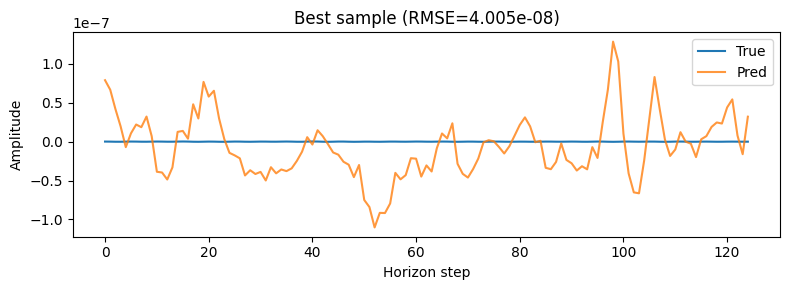

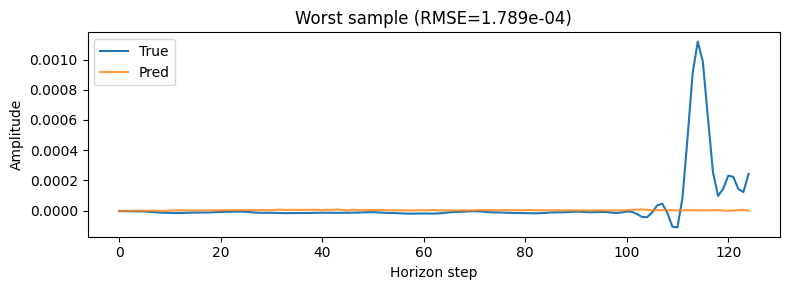

/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_36327/3060104437.py:161: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, vert=True, showfliers=False)


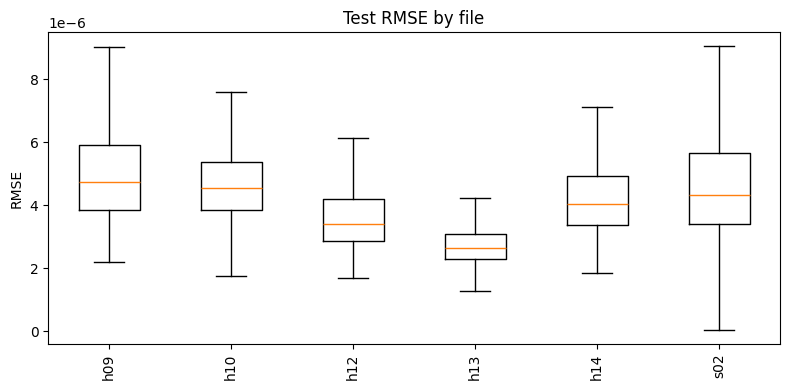

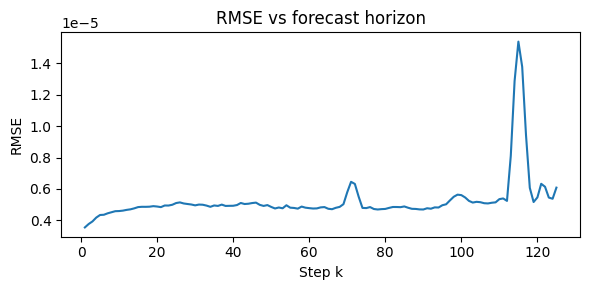

In [44]:
# ==== Test inference + denorm + metrics + save + plots (fixed) ====
import os, json, numpy as np, torch
import matplotlib.pyplot as plt
import pandas as pd
from torch.amp import autocast
from kanlib.metrics import mae, rmse  # используем свои MAE/RMSE, sMAPE ниже — стабильная версия

# ---------- helpers ----------
def smape_stable(y, yhat, eps=1e-8):
    """sMAPE, устойчива к нулям/крошечным значениям."""
    num = np.abs(yhat - y)
    den = np.abs(y) + np.abs(yhat) + eps
    return 200.0 * np.mean(num / den)

def nrmse(y, yhat, eps=1e-12):
    """NRMSE относительно std(y). Подходит для сравнения серий разного масштаба."""
    return np.sqrt(np.mean((yhat - y) ** 2)) / (np.std(y) + eps)

# 1) Load best checkpoint & predict on test
model.load_state_dict(torch.load(BEST, map_location=device))
model.eval()

@torch.no_grad()
def predict_loader(model, loader):
    preds, trues = [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        with autocast(device_type=("cuda" if device.type=="cuda" else "cpu"),
                      dtype=torch.float16 if device.type=="cuda" else torch.bfloat16,
                      enabled=use_amp):
            yhat = model(xb)
        preds.append(yhat.detach().cpu().numpy())
        trues.append(yb.detach().cpu().numpy())
    return np.concatenate(preds, axis=0), np.concatenate(trues, axis=0)

yhat_norm, ytrue_norm = predict_loader(model, test_loader)

# 2) Denormalize (using train stats)
def denorm_uni(arr):   # arr: [N,H]
    ch = int(target_ch_idx)
    return arr * (float(train_std[ch]) + 1e-6) + float(train_mean[ch])

def denorm_multi(arr): # arr: [N,C,H]
    return arr * (train_std[:, None] + 1e-6) + (train_mean[:, None])

tmode = cfg["task"]["target_mode"]
if tmode == "uni":
    yhat = denorm_uni(yhat_norm)
    ytrue = denorm_uni(ytrue_norm)
    H = yhat.shape[1]
else:
    yhat = denorm_multi(yhat_norm)
    ytrue = denorm_multi(ytrue_norm)
    H = yhat.shape[2]

# sanity-печать диапазонов после денорма
print("ytrue range:", float(np.min(ytrue)), "→", float(np.max(ytrue)))
print("yhat  range:", float(np.min(yhat)),  "→", float(np.max(yhat)))

# 3) Global metrics (avg over horizon; и по каналам, если multi)
if tmode == "uni":
    diff = (yhat - ytrue)
    rmse_per_sample = np.sqrt(np.mean(diff ** 2, axis=1))  # [N]
    mae_val   = float(mae(ytrue, yhat))
    rmse_val  = float(rmse(ytrue, yhat))
    smape_val = float(smape_stable(ytrue, yhat))
    nrmse_val = float(nrmse(ytrue, yhat))
    rmse_h = np.sqrt(np.mean(diff ** 2, axis=0))           # [H]
else:
    diff = (yhat - ytrue)
    rmse_per_sample = np.sqrt(np.mean(diff ** 2, axis=(1, 2)))  # [N]
    # для скалярных метрик усредняем по каналам
    ytrue_mean = ytrue.mean(axis=1)
    yhat_mean  = yhat.mean(axis=1)
    mae_val   = float(mae(ytrue_mean, yhat_mean))
    rmse_val  = float(rmse(ytrue_mean, yhat_mean))
    smape_val = float(smape_stable(ytrue_mean, yhat_mean))
    nrmse_val = float(nrmse(ytrue_mean, yhat_mean))
    rmse_h = np.sqrt(np.mean(diff ** 2, axis=(0, 1)))      # [H]

print(f"TEST: MAE={mae_val:.6e} | RMSE={rmse_val:.6e} | NRMSE={nrmse_val:.6e} | sMAPE={smape_val:.2f}%")

# 4) File-wise metrics (для boxplot)
# пробуем взять file_ids & test_mask из сплита; иначе — подгружаем
try:
    file_ids_test = file_ids[test_mask]
except NameError:
    file_ids_all = np.load(os.path.join(save_dir, "file_ids.npy"), allow_pickle=True)
    try:
        file_ids_test = file_ids_all[np.isin(file_ids_all, list(test_files))]
    except NameError:
        # fallback: подгоняем по длине
        if len(file_ids_all) >= len(rmse_per_sample):
            file_ids_test = file_ids_all[-len(rmse_per_sample):]
        else:
            # если вдруг короче — повторяем последнюю метку
            tail = np.full((len(rmse_per_sample) - len(file_ids_all),), file_ids_all[-1])
            file_ids_test = np.concatenate([file_ids_all, tail], axis=0)

df_file = pd.DataFrame({"file_id": file_ids_test, "rmse": rmse_per_sample})
by_file = (df_file.groupby("file_id")
           .agg(n_pairs=("rmse", "size"), rmse=("rmse", "mean"))
           .reset_index()
           .sort_values("file_id"))

# 5) Save metrics (повышенная точность)
out_dir = cfg["logging"]["out_dir"]
os.makedirs(out_dir, exist_ok=True)

metrics_dict = {
    "MAE": mae_val, "RMSE": rmse_val, "NRMSE": nrmse_val, "sMAPE": smape_val,
    "MAE_str": f"{mae_val:.6e}", "RMSE_str": f"{rmse_val:.6e}",
    "NRMSE_str": f"{nrmse_val:.6e}", "sMAPE_str": f"{smape_val:.2f}%"
}
with open(os.path.join(out_dir, "metrics_test.json"), "w") as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)

pd.DataFrame({"k": np.arange(1, H + 1), "rmse": rmse_h}).to_csv(
    os.path.join(out_dir, "metrics_test_horizon.csv"), index=False, float_format="%.6e"
)
by_file.to_csv(os.path.join(out_dir, "metrics_test_by_file.csv"), index=False, float_format="%.6e")

print("Saved:",
      os.path.join(out_dir, "metrics_test.json"), "|",
      os.path.join(out_dir, "metrics_test_horizon.csv"), "|",
      os.path.join(out_dir, "metrics_test_by_file.csv"))

# 6) Plots: best & worst, boxplot by file, horizon curve
best_idx = int(np.argmin(rmse_per_sample))
worst_idx = int(np.argmax(rmse_per_sample))

def plot_example(idx, title):
    plt.figure(figsize=(8, 3))
    if tmode == "uni":
        plt.plot(ytrue[idx], label="True")
        plt.plot(yhat[idx],  label="Pred", alpha=0.8)
    else:
        # если задан канал — показываем его; иначе — среднее по каналам
        try:
            plt.plot(ytrue[idx, target_ch_idx], label="True")
            plt.plot(yhat[idx,  target_ch_idx], label="Pred", alpha=0.8)
        except Exception:
            plt.plot(ytrue[idx].mean(axis=0), label="True (mean C)")
            plt.plot(yhat[idx].mean(axis=0),  label="Pred (mean C)", alpha=0.8)
    plt.title(title)
    plt.xlabel("Horizon step")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_example(best_idx,  f"Best sample (RMSE={rmse_per_sample[best_idx]:.3e})")
plot_example(worst_idx, f"Worst sample (RMSE={rmse_per_sample[worst_idx]:.3e})")

# boxplot by file (фиксированный порядок подпписей)
groups = [(fid, g["rmse"].values) for fid, g in df_file.groupby("file_id")]
labels = [fid for fid, _ in groups]
data   = [arr for _, arr in groups]

plt.figure(figsize=(8, 4))
plt.boxplot(data, labels=labels, vert=True, showfliers=False)
plt.xticks(rotation=90)
plt.title("Test RMSE by file")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

# horizon curve
plt.figure(figsize=(6, 3))
plt.plot(np.arange(1, H + 1), rmse_h)
plt.title("RMSE vs forecast horizon")
plt.xlabel("Step k")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()


In [47]:
# ==== Fine-tune KAN with horizon & spike-aware weighting (no dataloader changes) ====
import math, torch
import torch.nn as nn
import torch.optim as optim

# ---------- конфиг тюнинга ----------
FT_EPOCHS   = 12
FT_LR       = 1e-4
FT_WD       = 1e-5
H_POWER     = 2.0      # вес роста к концу горизонта: w_k = (k/H)^H_POWER
HUBER_DELTA = 1.0
SPIKE_KSIG  = 3.0      # что считаем "пиком": |y| > k * std(batch)
SPIKE_ALPHA = 2.0      # сколько раз сильнее штрафовать пики
FOCAL_GAMMA = 1.0      # усиление по величине остатка (0 = выкл)
CLIP_GRAD   = 1.0      # 0 чтобы отключить

device = next(model.parameters()).device

# ---------- loss с весами по горизонту, по пикам и "квазифокалом" ----------
class SpikeAwareWeightedHuber(nn.Module):
    def __init__(self, H, huber_delta=1.0, h_power=2.0, spike_ksig=3.0, spike_alpha=2.0, focal_gamma=1.0, eps=1e-12):
        super().__init__()
        self.delta = huber_delta
        self.spike_ksig = spike_ksig
        self.spike_alpha = spike_alpha
        self.focal_gamma = focal_gamma
        self.eps = eps
        # веса по горизонту (больше к концу)
        w = (torch.arange(1, H+1, dtype=torch.float32) / float(H)) ** float(h_power)
        self.register_buffer("w_h", w)  # [H]

    def forward(self, pred, target):
        """
        pred, target:
          uni:  [B,H]
          multi:[B,C,H] — усредняем по каналам для весов
        """
        if pred.dim() == 3:  # multi-channel
            # считаем loss на среднем по каналам (чтобы не усложнять)
            pred_ = pred.mean(dim=1)   # [B,H]
            targ_ = target.mean(dim=1) # [B,H]
        else:
            pred_, targ_ = pred, target  # [B,H]

        diff = pred_ - targ_
        adiff = diff.abs()

        # Huber по точкам
        hub = torch.where(adiff < self.delta, 0.5 * diff**2, self.delta * (adiff - 0.5 * self.delta))  # [B,H]

        # маска "пиков" в таргете относительно std по батчу
        # std считаем по времени (H), отдельно для каждого сэмпла
        std_b = targ_.std(dim=1, keepdim=True).clamp_min(self.eps)  # [B,1]
        spike_mask = (targ_.abs() > (self.spike_ksig * std_b)).float()  # [B,H]

        # итоговый вес = по горизонту * (1 + α*spike) * "фокал" по остатку
        w_h = self.w_h.view(1, -1)               # [1,H]
        w_spike = (1.0 + self.spike_alpha * spike_mask)  # [B,H]
        if self.focal_gamma > 0:
            # нормируем остаток batch-wise, чтобы не взрывался
            scale = (targ_.std() + self.eps).detach()
            focal = (adiff / (scale + self.eps) + 1e-3) ** self.focal_gamma
        else:
            focal = 1.0

        weights = w_h * w_spike * focal          # broadcast → [B,H]
        loss = (hub * weights).mean()
        return loss

# ---------- загрузка best чекпоинта и инициализация ----------
model.load_state_dict(torch.load(BEST, map_location=device))
model.train()

loss_fn = SpikeAwareWeightedHuber(
    H=H, huber_delta=HUBER_DELTA, h_power=H_POWER,
    spike_ksig=SPIKE_KSIG, spike_alpha=SPIKE_ALPHA, focal_gamma=FOCAL_GAMMA
).to(device)

optimizer = optim.Adam(model.parameters(), lr=FT_LR, weight_decay=FT_WD)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

# ---------- тюнинг-цикл ----------
best_ft_loss = math.inf
FT_PATH = os.path.join(cfg["logging"]["out_dir"], "best_kan.pt")

for epoch in range(1, FT_EPOCHS + 1):
    model.train()
    run_loss, nobs = 0.0, 0

    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        yhat = model(xb)
        loss = loss_fn(yhat, yb)
        loss.backward()

        if CLIP_GRAD and CLIP_GRAD > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)

        optimizer.step()

        bs = xb.size(0)
        run_loss += loss.item() * bs
        nobs += bs

    train_epoch_loss = run_loss / max(nobs, 1)
    print(f"[FT] Epoch {epoch}/{FT_EPOCHS} | train_loss={train_epoch_loss:.6e} | lr={optimizer.param_groups[0]['lr']:.2e}")

    # простая валидация: берём твою val_loader, если есть; иначе — scheduler по train_loss
    val_metric = train_epoch_loss
    try:
        model.eval()
        with torch.no_grad():
            vloss, vobs = 0.0, 0
            for xb, yb in val_loader:
                xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
                yhat = model(xb)
                v = loss_fn(yhat, yb).item()
                vloss += v * xb.size(0); vobs += xb.size(0)
            val_metric = vloss / max(vobs, 1)
        print(f"      val_loss={val_metric:.6e}")
    except NameError:
        pass

    scheduler.step(val_metric)

    if val_metric < best_ft_loss:
        best_ft_loss = val_metric
        torch.save(model.state_dict(), FT_PATH)
        print("      ✓ saved:", FT_PATH)

print("Fine-tune finished. Best val-like metric:", best_ft_loss)
print("Now re-run cell [12] with BEST=FT_PATH to evaluate the improved model.")


[FT] Epoch 1/12 | train_loss=1.122581e-01 | lr=1.00e-04
      val_loss=7.355849e-02
      ✓ saved: outputs/best_kan.pt
[FT] Epoch 2/12 | train_loss=1.104538e-01 | lr=1.00e-04
      val_loss=7.380477e-02
[FT] Epoch 3/12 | train_loss=1.101509e-01 | lr=1.00e-04
      val_loss=7.405118e-02
[FT] Epoch 4/12 | train_loss=1.086067e-01 | lr=1.00e-04
      val_loss=7.427675e-02
[FT] Epoch 5/12 | train_loss=1.079874e-01 | lr=5.00e-05
      val_loss=7.447505e-02
[FT] Epoch 6/12 | train_loss=1.088378e-01 | lr=5.00e-05
      val_loss=7.456931e-02


KeyboardInterrupt: 

## 13. Reprint Metrics in µV and Add Normalized RMSE
### 1) Scale predictions and ground truth to microvolts (µV) for domain-relevant reporting
### 2) Compute MAE, RMSE, and a numerically stable sMAPE (ignoring near-zero amplitudes)
### 3) Add normalized RMSE (nRMSE%) relative to RMS of the target series
### 4) Print summary and save metrics to `metrics_test_uv.json` for thesis usage


In [37]:
# ==== Reprint metrics in µV + add normalized RMSE ====
import json, os
import numpy as np
from kanlib.metrics import mae, rmse, smape

factor = 1e6  # V → µV

ytrue_uv = ytrue * factor
yhat_uv  = yhat  * factor

# stable sMAPE: ignore points with very small amplitude
def smape_stable(y_true, y_pred, tol=1e-3):  # tol in µV
    num = np.abs(y_pred - y_true)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = den >= tol
    if not np.any(mask):
        return float("nan")
    return float(100.0 * np.mean(num[mask] / den[mask]))

mae_uv   = mae(ytrue_uv, yhat_uv)
rmse_uv  = rmse(ytrue_uv, yhat_uv)
smape_uv = smape_stable(ytrue_uv, yhat_uv, tol=1e-3)

# normalized RMSE relative to RMS of target
rms_target = float(np.sqrt(np.mean(ytrue_uv**2)))
nrmse_pct  = float(100.0 * (rmse_uv / (rms_target + 1e-12)))

print(f"TEST (µV): MAE={mae_uv:.3e} µV | RMSE={rmse_uv:.3e} µV | nRMSE={nrmse_pct:.2f}% | sMAPE*={smape_uv:.2f}%")

# Save additional summary
out_dir = cfg["logging"]["out_dir"]
with open(os.path.join(out_dir, "metrics_test_uv.json"), "w") as f:
    json.dump({
        "MAE_uV": mae_uv, "RMSE_uV": rmse_uv,
        "nRMSE_percent": nrmse_pct, "sMAPE_stable_percent": smape_uv
    }, f, indent=2)
print("Saved:", os.path.join(out_dir, "metrics_test_uv.json"))


TEST (µV): MAE=3.514e+00 µV | RMSE=5.462e+00 µV | nRMSE=94.73% | sMAPE*=146.95%
Saved: outputs/metrics_test_uv.json


## 14. Fast Baselines (Persistence, Linear/Ridge, LSTM-lite) → Test Leaderboard
### 1) Build quick baselines:
###    • Persistence: repeat last observed value across the forecast horizon
###    • Linear/Ridge: closed-form linear baseline on raw (de-normalized) pairs
###   • LSTM-lite: small recurrent model with a short training budget
### 2) Evaluate all baselines on the same TEST split in physical units (after proper de-normalization)
### 3) Include the trained KAN result for comparison
### 4) Save a leaderboard CSV for the thesis


In [38]:
# ==== Fast baselines: Persistence, Lin/Ridge, LSTM-lite → leaderboard on test ====
import os, numpy as np, pandas as pd, torch, time

from kanlib.models.linridge import LinRidgeBaseline
from kanlib.models.lstm import LSTMLite
from kanlib.metrics import mae, rmse, smape
from kanlib.train import train_loop  # тот же цикл, что для KAN

tmode = cfg["task"]["target_mode"]
C, L  = X.shape[1], X.shape[2]
H     = Y.shape[1] if tmode=="uni" else Y.shape[2]

# ---------- 1) Persistence (ŷ = последнее значение окна, протянуть на H)
def predict_persistence(X_raw, H, tmode, ch_idx):
    if tmode == "uni":
        last = X_raw[:, ch_idx, -1][:, None]                 # [N,1]
        return np.repeat(last, H, axis=1).astype(np.float32) # [N,H]
    else:
        last = X_raw[:, :, -1][:, :, None]                   # [N,C,1]
        return np.repeat(last, H, axis=2).astype(np.float32) # [N,C,H]

# Сырые (денорм) выборки из сплита
X_tr, Y_tr = X_train, Y_train
X_te, Y_te = X_test,  Y_test

# --- Naive
yhat_pers = predict_persistence(X_te, H, tmode, target_ch_idx)
if tmode == "uni":
    mae_p  = mae(Y_te, yhat_pers); rmse_p = rmse(Y_te, yhat_pers); smape_p = smape(Y_te, yhat_pers)
else:
    mae_p  = mae(Y_te.mean(axis=1), yhat_pers.mean(axis=1))
    rmse_p = rmse(Y_te.mean(axis=1), yhat_pers.mean(axis=1))
    smape_p= smape(Y_te.mean(axis=1), yhat_pers.mean(axis=1))

# --- Lin/Ridge
lin = LinRidgeBaseline(alpha=1.0, target_mode=tmode, C=C, L=L, H=H).fit(X_tr, Y_tr)
yhat_lin = lin.predict(X_te)
if tmode == "uni":
    mae_l  = mae(Y_te, yhat_lin); rmse_l = rmse(Y_te, yhat_lin); smape_l = smape(Y_te, yhat_lin)
else:
    mae_l  = mae(Y_te.mean(axis=1), yhat_lin.mean(axis=1))
    rmse_l = rmse(Y_te.mean(axis=1), yhat_lin.mean(axis=1))
    smape_l= smape(Y_te.mean(axis=1), yhat_lin.mean(axis=1))

# --- LSTM-lite (FAST budget)
lstm_ckpt = os.path.join(cfg["logging"]["out_dir"], "best_lstm.pt")
lstm = LSTMLite(C=C, L=L, H=H, target_mode=tmode, hidden=32).to(device)  # hidden меньше для скорости
opt_lstm = torch.optim.Adam(lstm.parameters(), lr=1e-3)

def eval_lstm_on_test(lstm_model):
    @torch.no_grad()
    def _pred(loader):
        preds, trues = [], []
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            preds.append(lstm_model(xb).cpu().numpy())
            trues.append(yb.cpu().numpy())
        return np.concatenate(preds, 0), np.concatenate(trues, 0)

    yhat_norm, ytrue_norm = _pred(test_loader)
    if tmode == "uni":
        yhat  = yhat_norm  * (train_std[target_ch_idx] + 1e-6) + train_mean[target_ch_idx]
        ytrue = ytrue_norm * (train_std[target_ch_idx] + 1e-6) + train_mean[target_ch_idx]
        return (mae(ytrue, yhat), rmse(ytrue, yhat), smape(ytrue, yhat))
    else:
        yhat  = yhat_norm  * (train_std[:, None] + 1e-6) + train_mean[:, None]
        ytrue = ytrue_norm * (train_std[:, None] + 1e-6) + train_mean[:, None]
        return (mae(ytrue.mean(axis=1), yhat.mean(axis=1)),
                rmse(ytrue.mean(axis=1), yhat.mean(axis=1)),
                smape(ytrue.mean(axis=1), yhat.mean(axis=1)))

start = time.time()
if os.path.exists(lstm_ckpt):
    lstm.load_state_dict(torch.load(lstm_ckpt, map_location=device))
    lstm.eval()
else:
    best_lstm = train_loop(
        model=lstm,
        loaders={"train": train_loader, "val": val_loader},
        loss_fn=loss_fn,
        optimizer=opt_lstm,
        device=device,
        epochs=10,                      # <= быстрый бюджет
        patience=3,                     # <= ранняя остановка по-быстрому
        save_path=lstm_ckpt,
    )
    lstm.load_state_dict(torch.load(lstm_ckpt, map_location=device))
    lstm.eval()
print(f"LSTM-lite ready in {time.time()-start:.1f}s")

mae_ls, rmse_ls, smape_ls = eval_lstm_on_test(lstm)

# --- KAN (денорм уже считан ранее как ytrue/yhat)
if tmode == "uni":
    mae_k  = mae(ytrue, yhat); rmse_k = rmse(ytrue, yhat); smape_k = smape(ytrue, yhat)
else:
    mae_k  = mae(ytrue.mean(axis=1), yhat.mean(axis=1))
    rmse_k = rmse(ytrue.mean(axis=1), yhat.mean(axis=1))
    smape_k= smape(ytrue.mean(axis=1), yhat.mean(axis=1))

# --- Leaderboard
board = pd.DataFrame([
    {"model": "Naive(Persistence)", "MAE": mae_p,  "RMSE": rmse_p,  "sMAPE%": smape_p},
    {"model": "Lin/Ridge",          "MAE": mae_l,  "RMSE": rmse_l,  "sMAPE%": smape_l},
    {"model": "LSTM-lite (fast)",   "MAE": mae_ls, "RMSE": rmse_ls, "sMAPE%": smape_ls},
    {"model": "KAN",                "MAE": mae_k,  "RMSE": rmse_k,  "sMAPE%": smape_k},
]).sort_values("RMSE").reset_index(drop=True)

display(board)
out_csv = os.path.join(cfg["logging"]["out_dir"], "leaderboard_test.csv")
board.to_csv(out_csv, index=False)
print("Saved:", out_csv)


LSTM-lite ready in 10397.4s


,model,MAE,RMSE,sMAPE%
0,KAN,0.000004,0.000005,145.704269
1,LSTM-lite (fast),0.000003,0.000005,147.829020
2,Lin/Ridge,0.000004,0.000006,190.223384
3,Naive(Persistence),0.000005,0.000008,141.977417


Saved: outputs/leaderboard_test.csv


## 15. TCN-lite (FAST Baseline): Train on a Subset → Append to Leaderboard
### 1) Sample a small subset of train/val for quick turnaround (keeps test untouched)
### 2) Train a lightweight TCN (few blocks, small hidden) with a short budget
### 3) Run test-time inference, de-normalize back to physical units, compute metrics
### 4) Append/update the test leaderboard CSV with the TCN-lite row


In [39]:
# ==== TCN-lite (FAST baseline): train on subset + append to leaderboard ====
import os, time, numpy as np, pandas as pd, torch
from torch.utils.data import Subset, DataLoader

from kanlib.models.tcn import TCNLite
from kanlib.metrics import mae, rmse, smape
from kanlib.train import train_loop

tmode = cfg["task"]["target_mode"]
C, L  = X.shape[1], X.shape[2]
H     = Y.shape[1] if tmode == "uni" else Y.shape[2]

# 1) Подмножество для быстрого обучения
rng = np.random.default_rng(cfg.get("random_seed", 42))
FAST_TRAIN_N = min(4096, len(train_ds))
FAST_VAL_N   = min(1024, len(val_ds))
idx_tr = rng.choice(len(train_ds), size=FAST_TRAIN_N, replace=False)
idx_va = rng.choice(len(val_ds),   size=FAST_VAL_N,   replace=False)

train_fast = Subset(train_ds, idx_tr.tolist())
val_fast   = Subset(val_ds,   idx_va.tolist())

bs = min(256, cfg["train"]["batch_size"])
train_loader_fast = DataLoader(train_fast, batch_size=bs, shuffle=True,  drop_last=False)
val_loader_fast   = DataLoader(val_fast,   batch_size=bs, shuffle=False, drop_last=False)

# 2) Лёгкая TCN
tcn = TCNLite(C=C, L=L, H=H, target_mode=tmode, hidden=32, n_blocks=2, dropout=0.0).to(device)
opt = torch.optim.Adam(tcn.parameters(), lr=1e-3)
tcn_ckpt = os.path.join(cfg["logging"]["out_dir"], "best_tcn.pt")

start = time.time()
_ = train_loop(
    model=tcn,
    loaders={"train": train_loader_fast, "val": val_loader_fast},
    loss_fn=loss_fn,                # тот же лосс, что и у KAN/LSTM
    optimizer=opt,
    device=device,
    epochs=5,                       # быстрый бюджет
    patience=2,
    save_path=tcn_ckpt,
)
tcn.load_state_dict(torch.load(tcn_ckpt, map_location=device))
tcn.eval()
print(f"TCN-lite ready in {time.time()-start:.1f}s")

@torch.no_grad()
def _predict(loader):
    preds, trues = [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        preds.append(tcn(xb).cpu().numpy())
        trues.append(yb.cpu().numpy())
    return np.concatenate(preds, 0), np.concatenate(trues, 0)

yhat_n, ytrue_n = _predict(test_loader)

# 3) Денормализация и метрики
if tmode == "uni":
    yhat_tcn  = yhat_n  * (train_std[target_ch_idx] + 1e-6) + train_mean[target_ch_idx]
    ytrue_tcn = ytrue_n * (train_std[target_ch_idx] + 1e-6) + train_mean[target_ch_idx]
    mae_t  = mae(ytrue_tcn, yhat_tcn); rmse_t = rmse(ytrue_tcn, yhat_tcn); smape_t = smape(ytrue_tcn, yhat_tcn)
else:
    yhat_tcn  = yhat_n  * (train_std[:, None] + 1e-6) + train_mean[:, None]
    ytrue_tcn = ytrue_n * (train_std[:, None] + 1e-6) + train_mean[:, None]
    mae_t  = mae(ytrue_tcn.mean(axis=1), yhat_tcn.mean(axis=1))
    rmse_t = rmse(ytrue_tcn.mean(axis=1), yhat_tcn.mean(axis=1))
    smape_t= smape(ytrue_tcn.mean(axis=1), yhat_tcn.mean(axis=1))

# 4) Обновляем лидерборд
lb_path = os.path.join(cfg["logging"]["out_dir"], "leaderboard_test.csv")
board = pd.read_csv(lb_path) if os.path.exists(lb_path) else pd.DataFrame(columns=["model","MAE","RMSE","sMAPE%"])
board = board[board["model"] != "TCN-lite"]  # убрать старую строку, если была
board = pd.concat(
    [board, pd.DataFrame([{"model":"TCN-lite", "MAE": mae_t, "RMSE": rmse_t, "sMAPE%": smape_t}])],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

from IPython.display import display
display(board)
board.to_csv(lb_path, index=False)
print("Updated leaderboard:", lb_path)


TCN-lite ready in 32.7s


,model,MAE,RMSE,sMAPE%
0,KAN,0.000004,0.000005,145.704269
1,LSTM-lite (fast),0.000003,0.000005,147.829020
2,TCN-lite,0.000004,0.000006,157.077396
3,Lin/Ridge,0.000004,0.000006,190.223384
4,Naive(Persistence),0.000005,0.000008,141.977417


Updated leaderboard: outputs/leaderboard_test.csv


## 16. FAST HGB Baseline (as XGBoost fallback) → Update Leaderboard
### 1) Pool/flatten the temporal axis to reduce feature dimensionality
### 2) Subsample the training set for speed
### 3) Train a MultiOutput HistGradientBoostingRegressor with early stopping
### 4) Predict on TEST in raw (de-normalized) scale and compute metrics
### 5) Append/update the test leaderboard CSV with the HGB row


In [40]:
# ==== FAST HGB baseline (fallback for XGBoost) → update leaderboard ====
import os, numpy as np, pandas as pd
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from kanlib.metrics import mae, rmse, smape

rng = np.random.default_rng(cfg.get("random_seed", 42))
tmode = cfg["task"]["target_mode"]
C, L  = X.shape[1], X.shape[2]
H     = Y.shape[1] if tmode == "uni" else Y.shape[2]

# 1) Укрупняем временную ось (pool по времени) чтобы уменьшить размер признаков
POOL = 5  # 500 -> 100 признаков на канал
def flatten_pooled(Xarr, pool=POOL):
    N, C, L = Xarr.shape
    Lp = (L // pool) * pool
    Xc = Xarr[:, :, :Lp].reshape(N, C, Lp // pool, pool).mean(axis=-1)  # [N,C,L//pool]
    return Xc.reshape(N, C * (Lp // pool))

Xtr_flat = flatten_pooled(X_train, POOL)
Xte_flat = flatten_pooled(X_test,  POOL)

# 2) Ограничим обучающую выборку для скорости
MAXN = min(3000, len(Xtr_flat))
idx  = rng.choice(len(Xtr_flat), size=MAXN, replace=False)

# 3) Быстрый HGB с ранней остановкой
hgb = HistGradientBoostingRegressor(
    learning_rate=0.1,
    max_iter=60,                # меньше итераций
    max_depth=4,                # деревья мельче
    validation_fraction=0.1,
    early_stopping=True,
    n_iter_no_change=5,
    random_state=cfg.get("random_seed", 42)
)
reg = MultiOutputRegressor(hgb)

if tmode == "uni":
    ytr = Y_train[idx]                 # [N,H]
    yte = Y_test
else:
    ytr = Y_train[idx].reshape(len(idx), C * H)
    yte = Y_test.reshape(len(Y_test),  C * H)

print(f"Training HGB on {MAXN} samples with pooled features {Xtr_flat.shape[1]} dims …")
reg.fit(Xtr_flat[idx], ytr)

yhat_b = reg.predict(Xte_flat)
if tmode == "multi":
    yhat_b = yhat_b.reshape(-1, C, H)

# 4) Метрики в сыром масштабе
if tmode == "uni":
    mae_b  = mae(Y_test, yhat_b); rmse_b = rmse(Y_test, yhat_b); smape_b = smape(Y_test, yhat_b)
else:
    mae_b  = mae(Y_test.mean(axis=1), yhat_b.mean(axis=1))
    rmse_b = rmse(Y_test.mean(axis=1), yhat_b.mean(axis=1))
    smape_b= smape(Y_test.mean(axis=1), yhat_b.mean(axis=1))

# 5) Обновить лидборд
lb_path = os.path.join(cfg["logging"]["out_dir"], "leaderboard_test.csv")
board = pd.read_csv(lb_path) if os.path.exists(lb_path) else pd.DataFrame(columns=["model","MAE","RMSE","sMAPE%"])
board = board[board["model"] != "XGB/HGB (fast)"]
board = pd.concat([board, pd.DataFrame([{"model":"XGB/HGB (fast)", "MAE": mae_b, "RMSE": rmse_b, "sMAPE%": smape_b}])],
                  ignore_index=True).sort_values("RMSE").reset_index(drop=True)
from IPython.display import display
display(board)
board.to_csv(lb_path, index=False)
print("Updated leaderboard:", lb_path)


Training HGB on 3000 samples with pooled features 900 dims …


,model,MAE,RMSE,sMAPE%
0,KAN,0.000004,0.000005,145.704269
1,LSTM-lite (fast),0.000003,0.000005,147.829020
2,XGB/HGB (fast),0.000004,0.000006,174.051161
3,TCN-lite,0.000004,0.000006,157.077396
4,Lin/Ridge,0.000004,0.000006,190.223384
5,Naive(Persistence),0.000005,0.000008,141.977417


Updated leaderboard: outputs/leaderboard_test.csv


## 17. Robustness to Input Missingness (p ∈ {5, 10, 20}%)
### 1) Wrap the normalized TEST dataset with a masking layer that zeroes a fraction p of inputs
### 2) Evaluate neural models (KAN, LSTM-lite, TCN-lite) under masked inputs and then de-normalize for metrics
### 3) For classical baselines (Persistence, Linear/Ridge), apply masking in RAW space by imputing with train means
### 4) Collect MAE / RMSE / sMAPE for each model across missingness levels and save a CSV report


In [41]:
# ==== Robustness: test under input missingness p ∈ {5, 10, 20}% ====
import numpy as np, pandas as pd, torch, os
from torch.utils.data import Dataset, DataLoader
from kanlib.metrics import mae, rmse, smape

tmode = cfg["task"]["target_mode"]
C, L  = X.shape[1], X.shape[2]
H     = Y.shape[1] if tmode=="uni" else Y.shape[2]

# 1) Masking wrapper for the normalized test_ds (zero out a fraction p)
class MaskedDataset(Dataset):
    def __init__(self, base_ds, p_missing: float, seed=42):
        self.base = base_ds
        self.p = float(p_missing)
        self.rng = np.random.default_rng(seed)
    def __len__(self): 
        return len(self.base)
    def __getitem__(self, i):
        x, y = self.base[i]  # x: [C,L] already normalized (mean≈0)
        if self.p > 0:
            m = torch.from_numpy(self.rng.random(size=x.shape)).to(x.dtype)
            m = (m < self.p).to(x.dtype)   # mask=1 → missing
            x = x * (1 - m)                # zero imputation (≈ train mean in z-space)
        return x, y

def predict_model(model, loader):
    ys, yh = [], []
    model.eval()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yhat = model(xb).cpu().numpy()
            ys.append(yb.cpu().numpy()); yh.append(yhat)
    y_true = np.concatenate(ys, 0)
    y_pred = np.concatenate(h, 0) if (h:=yh) else np.zeros_like(y_true)
    return y_true, y_pred

# 2) Helper: de-normalize neural-model outputs back to physical scale
def denorm_preds(yhat_norm, ytrue_norm):
    if tmode == "uni":
        yhat  = yhat_norm  * (train_std[target_ch_idx] + 1e-6) + train_mean[target_ch_idx]
        ytrue = ytrue_norm * (train_std[target_ch_idx] + 1e-6) + train_mean[target_ch_idx]
    else:
        yhat  = yhat_norm  * (train_std[:, None] + 1e-6) + train_mean[:, None]
        ytrue = ytrue_norm * (train_std[:, None] + 1e-6) + train_mean[:, None]
    return ytrue, yhat

# 3) Apply missingness in RAW space for classical baselines (impute with train mean per channel)
def apply_mask_raw(X_raw, p, train_mean_vec, seed=42):
    rng = np.random.default_rng(seed)
    Xc = X_raw.copy()
    M = rng.random(size=Xc.shape) < p
    for c in range(C):
        Xc[:, c, :][M[:, c, :]] = float(train_mean_vec[c])
    return Xc

# 4) Collect robustness results
rows = []
PS = [0.05, 0.10, 0.20]
bs = min(256, cfg["train"]["batch_size"])

for p in PS:
    # Neural models: masked normalized inputs
    te_masked = MaskedDataset(test_ds, p_missing=p, seed=cfg.get("random_seed", 42))
    te_loader_masked = DataLoader(te_masked, batch_size=bs, shuffle=False, drop_last=False)

    # KAN
    ytrue_n, yhat_n = predict_model(model, te_loader_masked)
    ytrue_d, yhat_d = denorm_preds(yhat_n, ytrue_n)
    rows.append({"p": p, "model": "KAN", "MAE": mae(ytrue_d, yhat_d), "RMSE": rmse(ytrue_d, yhat_d), "sMAPE%": smape(ytrue_d, yhat_d)})

    # LSTM
    lstm.load_state_dict(torch.load(os.path.join(cfg["logging"]["out_dir"], "best_lstm.pt"), map_location=device))
    ytrue_n, yhat_n = predict_model(lstm, te_loader_masked)
    ytrue_d, yhat_d = denorm_preds(yhat_n, ytrue_n)
    rows.append({"p": p, "model": "LSTM-lite (fast)", "MAE": mae(ytrue_d, yhat_d), "RMSE": rmse(ytrue_d, yhat_d), "sMAPE%": smape(ytrue_d, yhat_d)})

    # TCN
    tcn.load_state_dict(torch.load(os.path.join(cfg["logging"]["out_dir"], "best_tcn.pt"), map_location=device))
    ytrue_n, yhat_n = predict_model(tcn, te_loader_masked)
    ytrue_d, yhat_d = denorm_preds(yhat_n, ytrue_n)
    rows.append({"p": p, "model": "TCN-lite (fast)", "MAE": mae(ytrue_d, yhat_d), "RMSE": rmse(ytrue_d, yhat_d), "sMAPE%": smape(ytrue_d, yhat_d)})

    # Classical baselines: mask RAW inputs (impute with train mean), then predict
    X_te_mask = apply_mask_raw(X_test, p, train_mean, seed=cfg.get("random_seed", 42))

    # Naive (persistence)
    if tmode == "uni":
        last = X_te_mask[:, target_ch_idx, -1][:, None]
        yhat_p = np.repeat(last, H, axis=1).astype(np.float32)
        rows.append({"p": p, "model": "Naive(Persistence)", "MAE": mae(Y_test, yhat_p), "RMSE": rmse(Y_test, yhat_p), "sMAPE%": smape(Y_test, yhat_p)})
    else:
        last = X_te_mask[:, :, -1][:, :, None]
        yhat_p = np.repeat(last, H, axis=2).astype(np.float32)
        rows.append({"p": p, "model": "Naive(Persistence)",
                     "MAE": mae(Y_test.mean(axis=1), yhat_p.mean(axis=1)),
                     "RMSE": rmse(Y_test.mean(axis=1), yhat_p.mean(axis=1)),
                     "sMAPE%": smape(Y_test.mean(axis=1), yhat_p.mean(axis=1))})

    # Linear/Ridge on masked RAW inputs (trained on clean RAW, as agreed)
    from kanlib.models.linridge import LinRidgeBaseline
    lin_mask = LinRidgeBaseline(alpha=1.0, target_mode=tmode, C=C, L=L, H=H).fit(X_train, Y_train)
    yhat_lm = lin_mask.predict(X_te_mask)
    if tmode == "uni":
        rows.append({"p": p, "model": "Lin/Ridge",
                     "MAE": mae(Y_test, yhat_lm), "RMSE": rmse(Y_test, yhat_lm), "sMAPE%": smape(Y_test, yhat_lm)})
    else:
        rows.append({"p": p, "model": "Lin/Ridge",
                     "MAE": mae(Y_test.mean(axis=1), yhat_lm.mean(axis=1)),
                     "RMSE": rmse(Y_test.mean(axis=1), yhat_lm.mean(axis=1)),
                     "sMAPE%": smape(Y_test.mean(axis=1), yhat_lm.mean(axis=1))})

rob = pd.DataFrame(rows).sort_values(["p","RMSE"]).reset_index(drop=True)
from IPython.display import display
display(rob)

rob_path = os.path.join(cfg["logging"]["out_dir"], "robustness_missingness.csv")
rob.to_csv(rob_path, index=False)
print("Saved:", rob_path)


,p,model,MAE,RMSE,sMAPE%
0,0.05,LSTM-lite (fast),0.000003,0.000005,148.766446
1,0.05,KAN,0.000004,0.000006,145.891929
2,0.05,TCN-lite (fast),0.000004,0.000006,157.256293
3,0.05,Lin/Ridge,0.000004,0.000006,190.223527
4,0.05,Naive(Persistence),0.000005,0.000007,144.311118
5,0.10,LSTM-lite (fast),0.000003,0.000005,149.734998
6,0.10,KAN,0.000004,0.000006,145.947003
7,0.10,TCN-lite (fast),0.000004,0.000006,157.506323
8,0.10,Lin/Ridge,0.000004,0.000006,190.223610
9,0.10,Naive(Persistence),0.000005,0.000007,146.831477


Saved: outputs/robustness_missingness.csv


## 18. KAN Permutation Importance by Channel (Test Subset)
### 1) Subsample TEST for speed and cache normalized tensors on CPU
### 2) Compute baseline RMSE (after de-normalization)
### 3) For each channel c: permute X[:, c, :] across samples, re-evaluate RMSE
### 4) Report ΔRMSE = RMSE_perm − RMSE_base as an importance score per channel
### 5) Save CSV and plot a horizontal bar chart (largest ΔRMSE at the top)


,channel,delta_RMSE,rmse_perm
0,Pz,3.097903e-07,0.000005
1,Fp1,7.271501e-08,0.000005
2,Fp2,5.447282e-08,0.000005
3,O1,4.827234e-08,0.000005
4,Cz,2.052911e-08,0.000005
5,Fz,3.718469e-09,0.000005
6,O2,3.623427e-09,0.000005
7,C3,1.518856e-09,0.000005
8,C4,-5.290076e-09,0.000005


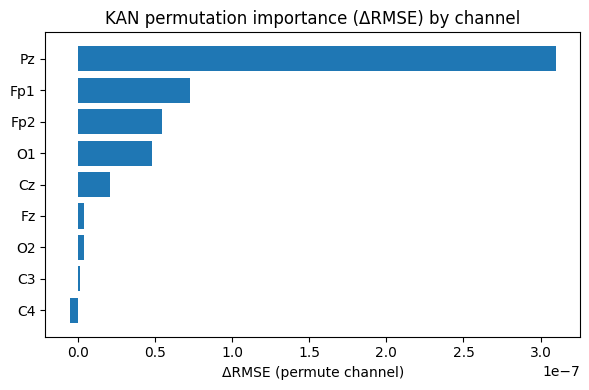

Saved: outputs/kan_permutation_importance.csv


In [42]:
# ==== KAN permutation importance by channel (test subset) ====
import os, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from torch.utils.data import Subset, DataLoader

rng = np.random.default_rng(cfg.get("random_seed", 42))
C = X.shape[1]
channels = np.load(os.path.join(save_dir, "channels.npy"), allow_pickle=True).tolist()

# Subsample TEST for speed
N_EVAL = min(2048, len(test_ds))
idx = rng.choice(len(test_ds), size=N_EVAL, replace=False)
subset = Subset(test_ds, idx.tolist())
loader = DataLoader(subset, batch_size=min(256, cfg["train"]["batch_size"]), shuffle=False)

# Load BEST and compute baseline RMSE (de-normalized)
model.load_state_dict(torch.load(BEST, map_location=device))

@torch.no_grad()
def _predict(model, loader):
    yh, yt = [], []
    model.eval()
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yh.append(model(xb).cpu().numpy())
        yt.append(yb.cpu().numpy())
    return np.concatenate(yt, 0), np.concatenate(yh, 0)

ytrue_n, yhat_n = _predict(model, loader)

def _denorm(yhat_n, ytrue_n):
    if cfg["task"]["target_mode"] == "uni":
        yhat  = yhat_n  * (train_std[target_ch_idx] + 1e-6) + train_mean[target_ch_idx]
        ytrue = ytrue_n * (train_std[target_ch_idx] + 1e-6) + train_mean[target_ch_idx]
    else:
        yhat  = yhat_n  * (train_std[:, None] + 1e-6) + train_mean[:, None]
        ytrue = ytrue_n * (train_std[:, None] + 1e-6) + train_mean[:, None]
    return ytrue, yhat

ytrue_b, yhat_b = _denorm(yhat_n, ytrue_n)
rmse_base = rmse(ytrue_b, yhat_b)

# Cache normalized X/Y for the subset (so we can permute on CPU)
Xn = np.empty((N_EVAL, C, X.shape[2]), dtype=np.float32)
Yn = np.empty_like(ytrue_n)
for i, (x, y) in enumerate(subset):
    Xn[i] = x.numpy()
    Yn[i] = y.numpy()

def _eval_with_Xn(Xn_perm):
    ds = torch.utils.data.TensorDataset(torch.from_numpy(Xn_perm), torch.from_numpy(Yn))
    dl = DataLoader(ds, batch_size=min(256, cfg["train"]["batch_size"]), shuffle=False)
    ytrue_n2, yhat_n2 = _predict(model, dl)
    ytrue_d, yhat_d   = _denorm(yhat_n2, ytrue_n2)
    return rmse(ytrue_d, yhat_d)

rows = []
for c in range(C):
    Xp = Xn.copy()
    perm = rng.permutation(N_EVAL)
    Xp[:, c, :] = Xp[perm, c, :]
    rmse_perm = _eval_with_Xn(Xp)
    rows.append({
        "channel": channels[c] if c < len(channels) else f"ch{c}",
        "delta_RMSE": float(rmse_perm - rmse_base),
        "rmse_perm": float(rmse_perm)
    })

imp = pd.DataFrame(rows).sort_values("delta_RMSE", ascending=False).reset_index(drop=True)
from IPython.display import display
display(imp)

# Save and plot
out_dir = cfg["logging"]["out_dir"]
imp.to_csv(os.path.join(out_dir, "kan_permutation_importance.csv"), index=False)

plt.figure(figsize=(6, 4))
plt.barh(imp["channel"], imp["delta_RMSE"])
plt.gca().invert_yaxis()
plt.title("KAN permutation importance (ΔRMSE) by channel")
plt.xlabel("ΔRMSE (permute channel)")
plt.tight_layout()
plt.show()

print("Saved:", os.path.join(out_dir, "kan_permutation_importance.csv"))


## 19. Export Thesis-Ready Tables & Plots
### 1) Compute and save metrics in microvolts (µV), incl. nRMSE%
### 2) Save “best” and “worst” true vs. pred examples as PNGs
### 3) Render a leaderboard bar chart from `leaderboard_test.csv`


In [43]:
# ==== Export thesis-ready tables & plots ====
import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt

out_dir = cfg["logging"]["out_dir"]
os.makedirs(out_dir, exist_ok=True)

# 1) Метрики в µV + nRMSE%
factor = 1e6
def smape_stable(y_true, y_pred, tol=1e-3):  # tol в µV
    num = np.abs(y_pred - y_true)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = den >= tol
    if not np.any(mask): return float("nan")
    return float(100.0 * np.mean(num[mask] / den[mask]))

if cfg["task"]["target_mode"] == "uni":
    ytrue_uv = ytrue * factor; yhat_uv = yhat * factor
else:
    ytrue_uv = ytrue.mean(axis=1) * factor
    yhat_uv  = yhat.mean(axis=1)  * factor

mae_uv   = float(np.mean(np.abs(yhat_uv - ytrue_uv)))
rmse_uv  = float(np.sqrt(np.mean((yhat_uv - ytrue_uv)**2)))
rms_tgt  = float(np.sqrt(np.mean(ytrue_uv**2))) + 1e-12
nrmse_pct = float(100.0 * rmse_uv / rms_tgt)
smape_uv = smape_stable(ytrue_uv, yhat_uv, tol=1e-3)

with open(os.path.join(out_dir, "metrics_test_uv.json"), "w") as f:
    json.dump({"MAE_uV": mae_uv, "RMSE_uV": rmse_uv,
               "nRMSE_percent": nrmse_pct, "sMAPE_stable_percent": smape_uv}, f, indent=2)

# 2) Сохранить "true vs pred" (лучший/худший кейсы)
rmse_per_sample = np.sqrt(np.mean((yhat - ytrue)**2, axis=-1)) if cfg["task"]["target_mode"]=="uni" \
                  else np.sqrt(np.mean((yhat.mean(axis=1)-ytrue.mean(axis=1))**2, axis=-1))
best_idx  = int(np.argmin(rmse_per_sample))
worst_idx = int(np.argmax(rmse_per_sample))

def save_example(idx, name):
    plt.figure(figsize=(8,3))
    if cfg["task"]["target_mode"]=="uni":
        plt.plot(ytrue[idx], label="True"); plt.plot(yhat[idx], label="Pred", alpha=0.8)
    else:
        plt.plot(ytrue[idx].mean(axis=0), label="True (mean C)")
        plt.plot(yhat[idx].mean(axis=0), label="Pred (mean C)", alpha=0.8)
    plt.xlabel("Horizon step"); plt.ylabel("Amplitude (V)"); plt.legend()
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, f"{name}.png"), dpi=180); plt.close()

save_example(best_idx,  "case_best")
save_example(worst_idx, "case_worst")

# 3) Лидерборд — столбчатый график
lb = pd.read_csv(os.path.join(out_dir, "leaderboard_test.csv"))
plt.figure(figsize=(6,3))
plt.bar(lb["model"], lb["RMSE"])
plt.ylabel("RMSE (V)"); plt.title("KAN vs Baselines (test)")
plt.xticks(rotation=20); plt.tight_layout()
plt.savefig(os.path.join(out_dir, "leaderboard_bar.png"), dpi=180); plt.close()

# 4) RMSE по горизонту (если файл есть)
hpath = os.path.join(out_dir, "metrics_test_horizon.csv")
if os.path.exists(hpath):
    dfh = pd.read_csv(hpath)
    plt.figure(figsize=(6,3)); plt.plot(dfh["k"], dfh["rmse"])
    plt.xlabel("Step k"); plt.ylabel("RMSE (V)"); plt.title("RMSE vs forecast horizon")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, "rmse_horizon.png"), dpi=180); plt.close()

print("Saved figures to:", out_dir)


Saved figures to: outputs


# New training (v2) — CLIPPED TTR + proper de-normalization


[v2] Split: train=16713 | val=6211 | test=5883
[v2] Saved per-file stats: outputs_v2/per_file_stats.npy
[v2] TTR.s = 0.4386
[v2] Datasets built. Channels used: ['Pz', 'Fp1', 'Fp2', 'O1', 'Cz']
checkpoint directory created: ./model
saving model version 0.0
[v2] KAN | mode=uni | C=5 L=500 H=125 | params=170,378 | device=cpu


[v2] Epoch 1/20:   0%|          | 0/66 [00:00<?, ?it/s]

[v2][END] Epoch 01 | val_RMSE=7.474437e-06 | nRMSE=1.094 | best=7.474437e-06 | stale=0/3 | lr=1.00e-03


[v2] Epoch 2/20:   0%|          | 0/66 [00:00<?, ?it/s]

[v2][END] Epoch 02 | val_RMSE=7.279571e-06 | nRMSE=1.065 | best=7.279571e-06 | stale=0/3 | lr=1.00e-03


...

[v2][END] Epoch 05 | val_RMSE=7.117968e-06 | nRMSE=1.041 | best=6.939239e-06 | stale=1/3 | lr=1.00e-03


[v2] Epoch 6/20:   0%|          | 0/66 [00:00<?, ?it/s]

[v2][END] Epoch 06 | val_RMSE=7.072689e-06 | nRMSE=1.035 | best=6.939239e-06 | stale=2/3 | lr=1.00e-03


[v2] Epoch 7/20:   0%|          | 0/66 [00:00<?, ?it/s]

[v2][END] Epoch 07 | val_RMSE=7.229867e-06 | nRMSE=1.058 | best=6.939239e-06 | stale=3/3 | lr=1.00e-03
[v2] Early stopping at epoch 7. Best val_RMSE=6.939239e-06
Saved v2 checkpoints: best_kan_v2.pt last_kan_v2.pt final_kan_v2.pt in /Users/tairakhayev/Desktop/ThesisProject/TimeSeriesForecast/outputs_v2
[v2][TEST] RMSE=5.098123e-06 | nRMSE=0.980


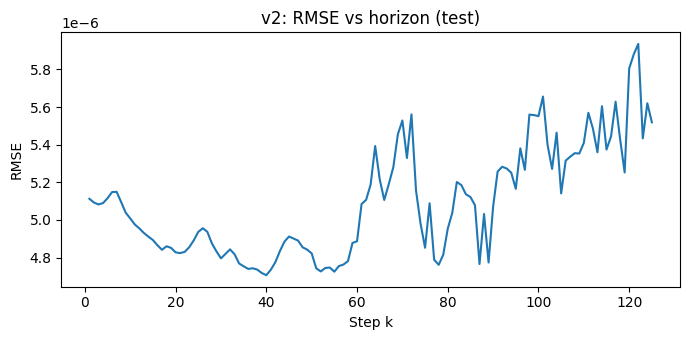

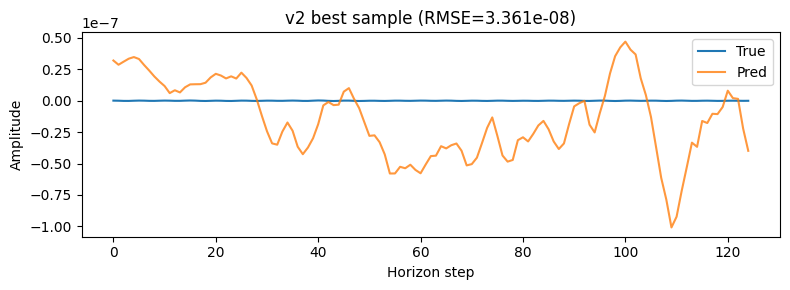

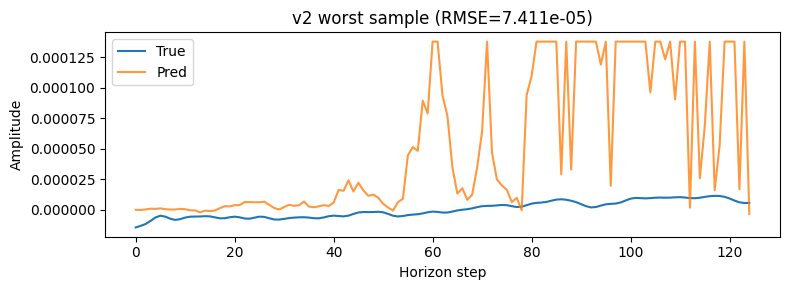

In [54]:
# =========================
# [20] New training (v2) — CLIPPED TTR + proper de-normalization
# =========================
import os, json, math, numpy as np, torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from dataclasses import dataclass
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# --- safety: device & AMP ---
try:
    device  # re-use if defined
except NameError:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = (device.type == "cuda")
from torch.amp import autocast, GradScaler
scaler = GradScaler("cuda", enabled=use_amp)

# ---------- paths (v2) ----------
PROC_V2 = Path("./processed_v2")
OUT_V2  = Path("./outputs_v2")
PROC_V2.mkdir(parents=True, exist_ok=True)
OUT_V2.mkdir(parents=True, exist_ok=True)

# keep old outputs intact
CHANNELS_KEEP = ["Pz","Fp1","Fp2","O1","Cz"]
with open(OUT_V2 / "channels_used.json", "w") as f:
    json.dump({"channels": CHANNELS_KEEP}, f, indent=2)

# ---------- load raw artifacts from original processed/ ----------
save_dir = Path(cfg["data"]["out_dir"])  # == "./processed"
X = np.load(save_dir / "X_raw.npy")               # [N, C, L]
Y = np.load(save_dir / "Y_raw.npy")               # [N, H] or [N, C, H]
file_ids = np.load(save_dir / "file_ids.npy", allow_pickle=True)
channels = np.load(save_dir / "channels.npy", allow_pickle=True).tolist()

tmode = cfg["task"]["target_mode"]        # "uni" | "multi"
L     = int(cfg["task"]["L"])
H     = int(cfg["task"]["H"])

# ---------- select channels ----------
keep_idx = [channels.index(ch) for ch in CHANNELS_KEEP if ch in channels]
assert len(keep_idx) >= 3, f"Too few channels kept: {keep_idx}"
X = X[:, keep_idx, :]
channels_v2 = [channels[i] for i in keep_idx]
C = len(channels_v2)

# target channel idx for "uni"
if tmode == "uni":
    target_ch_name = cfg["task"]["target_channel"]
    if target_ch_name not in channels_v2:
        target_ch_name = "Pz" if "Pz" in channels_v2 else channels_v2[0]
    target_ch_idx = channels_v2.index(target_ch_name)
else:
    target_ch_idx = 0  # unused in multi

# ---------- split by file ----------
from kanlib.splits import split_by_file
ratios = tuple(cfg["split"]["ratios"])
train_files, val_files, test_files = split_by_file(file_ids, ratios=ratios, seed=cfg.get("random_seed", 42))
train_mask = np.isin(file_ids, list(train_files))
val_mask   = np.isin(file_ids, list(val_files))
test_mask  = np.isin(file_ids, list(test_files))

X_train, Y_train = X[train_mask], Y[train_mask]
X_val,   Y_val   = X[val_mask],   Y[val_mask]
X_test,  Y_test  = X[test_mask],  Y[test_mask]
file_ids_train   = file_ids[train_mask]
file_ids_val     = file_ids[val_mask]
file_ids_test    = file_ids[test_mask]

print(f"[v2] Split: train={len(X_train)} | val={len(X_val)} | test={len(X_test)}")

# ---------- per-file stats on TRAIN only ----------
def per_file_stats(file_ids_arr, Y_arr, channels_v2, mode, target_ch_idx):
    stats = {}
    if mode == "multi":
        Ym = Y_arr.mean(axis=1)  # [N,H]
    else:
        Ym = Y_arr if Y_arr.ndim == 2 else Y_arr[:, target_ch_idx, :]
    for fid in np.unique(file_ids_arr):
        m = (file_ids_arr == fid)
        yfid = Ym[m]
        mu = float(np.mean(yfid))
        sd = float(np.std(yfid) + 1e-8)
        stats[str(fid)] = {"mean": mu, "std": sd}
    return stats

per_file = per_file_stats(file_ids_train, Y_train, channels_v2, tmode, target_ch_idx)
np.save(OUT_V2 / "per_file_stats.npy", per_file)
print(f"[v2] Saved per-file stats:", (OUT_V2 / "per_file_stats.npy").as_posix())

# ---------- target transform (signed log) ----------
@dataclass
class TargetTransform:
    s: float = None
    def fit(self, Y_fit):
        yabs = np.abs(Y_fit.reshape(-1))
        self.s = float(np.median(yabs) + 1e-8)
    def fwd(self, y):
        return np.sign(y) * np.log1p(np.abs(y) / self.s)
    def inv(self, yt):
        return np.sign(yt) * (np.expm1(np.abs(yt)) * self.s)

# используем TRAIN таргет выбранного канала/среднего
Y_train_base = Y_train.mean(axis=1) if tmode == "multi" else Y_train
global_mu = float(np.mean(Y_train_base))
global_sd = float(np.std(Y_train_base) + 1e-8)

# --- fit TTR на пер-файл-нормированном train-таргете ---
def collect_normed_train_targets(Y_train, file_ids_train):
    Yb = Y_train.mean(axis=1) if tmode == "multi" else Y_train  # [N,H]
    ys = []
    for i, fid in enumerate(file_ids_train):
        st = per_file.get(str(fid))
        if st is None:
            m, s = global_mu, global_sd
        else:
            m, s = float(st["mean"]), float(st["std"])
        ys.append((Yb[i] - m) / s)
    return np.concatenate(ys, axis=0)

normed_train_flat = collect_normed_train_targets(Y_train, file_ids_train)
TTR = TargetTransform()
TTR.fit(normed_train_flat)
print(f"[v2] TTR.s = {TTR.s:.4f}")

# ---------- Dataset with per-file norm + oversampling + (m,s) return ----------
from torch.utils.data import Dataset, DataLoader, Sampler

class ForecastDatasetV2(Dataset):
    def __init__(self, X, Y, file_ids, per_file_map, tmode, target_ch_idx, apply_ttr=True, last_k_focus=0.3):
        self.X, self.Y = X.astype(np.float32), Y.astype(np.float32)
        self.file_ids = file_ids
        self.pf = per_file_map
        self.tmode = tmode
        self.target_ch_idx = int(target_ch_idx)
        self.apply_ttr = apply_ttr
        self.last_k = float(last_k_focus)

        Yshow = (self.Y.mean(axis=1) if tmode == "multi" else self.Y)
        self.std_win = np.std(Yshow, axis=1)
        k0 = int(max(1, round((1.0 - self.last_k) * Yshow.shape[1])))
        self.tail_energy = np.sqrt(np.mean(Yshow[:, k0:]**2, axis=1))

    def __len__(self):
        return len(self.X)

    def _get_mu_sigma(self, fid):
        st = self.pf.get(str(fid))
        if st is None:
            return float(global_mu), float(global_sd)
        return float(st["mean"]), float(st["std"])

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.Y[idx]
        fid = self.file_ids[idx]
        m, s = self._get_mu_sigma(fid)

        # per-file normalization to z-space
        x = (x - m) / s
        y = (y - m) / s

        # target transform in that space
        if self.apply_ttr:
            if self.tmode == "multi":
                y = np.stack([TTR.fwd(y[c]) for c in range(y.shape[0])], axis=0).astype(np.float32)
            else:
                y = TTR.fwd(y).astype(np.float32)

        return (
            torch.from_numpy(x),
            torch.from_numpy(y),
            torch.tensor(m, dtype=torch.float32),
            torch.tensor(s, dtype=torch.float32),
        )

class SpikeBalancedSampler(Sampler):
    def __init__(self, ds: ForecastDatasetV2, batch_size: int, q=0.8, length=None):
        self.ds = ds
        self.bs = int(batch_size)
        self.q = float(q)
        N = len(ds)
        self.length = length or N
        q_std  = np.quantile(ds.std_win, q)
        q_tail = np.quantile(ds.tail_energy, q)
        self.pool_spike = np.where((ds.std_win >= q_std) | (ds.tail_energy >= q_tail))[0]
        self.pool_all   = np.arange(N)
        if len(self.pool_spike) == 0:
            self.pool_spike = self.pool_all
    def __iter__(self):
        N = self.length
        half = max(1, self.bs // 2)
        idxs = []
        while len(idxs) < N:
            a = np.random.choice(self.pool_all,   size=half, replace=True)
            b = np.random.choice(self.pool_spike, size=half, replace=True)
            mix = np.concatenate([a, b])
            np.random.shuffle(mix)
            idxs.extend(mix.tolist())
        return iter(idxs[:N])
    def __len__(self):
        return self.length

# ---------- build datasets & loaders ----------
train_ds = ForecastDatasetV2(X_train, Y_train, file_ids_train, per_file, tmode, target_ch_idx, apply_ttr=True,  last_k_focus=0.3)
val_ds   = ForecastDatasetV2(X_val,   Y_val,   file_ids_val,   per_file, tmode, target_ch_idx, apply_ttr=True,  last_k_focus=0.3)
test_ds  = ForecastDatasetV2(X_test,  Y_test,  file_ids_test,  per_file, tmode, target_ch_idx, apply_ttr=True,  last_k_focus=0.3)

bs = int(cfg["train"]["batch_size"])
num_workers = 6 if device.type == "cuda" else 0
pin = (device.type == "cuda")

def _dl_kwargs(shuffle=False):
    kw = dict(batch_size=bs, shuffle=shuffle, num_workers=num_workers, pin_memory=pin)
    if num_workers > 0:
        kw.update(persistent_workers=True, prefetch_factor=4)
    return kw

train_loader = DataLoader(train_ds, sampler=SpikeBalancedSampler(train_ds, batch_size=bs, q=0.8), **_dl_kwargs(False))
val_loader   = DataLoader(val_ds,   **_dl_kwargs(False))
test_loader  = DataLoader(test_ds,  **_dl_kwargs(False))

print(f"[v2] Datasets built. Channels used: {channels_v2}")

# ---------- model ----------
from kanlib.models.kan import KANRegressor
model_v2 = KANRegressor(
    C=C, L=L, H=H,
    pool=cfg["model"]["params"].get("pool", 20),
    hidden=tuple(cfg["model"]["params"].get("hidden", [64, 32])),
    target_mode=tmode,
    grid=cfg["model"]["params"].get("grid", 2),
    k=cfg["model"]["params"].get("k", 3)
).to(device)

n_params = sum(p.numel() for p in model_v2.parameters() if p.requires_grad)
print(f"[v2] KAN | mode={tmode} | C={C} L={L} H={H} | params={n_params:,} | device={device}")

# ---------- loss: Huber + horizon/spike weights + CLIP ----------
# более консервативный клип → меньше «взрывов» при inverse
Y_T_CLIP = 3.8

class SpikeAwareWeightedHuber(nn.Module):
    def __init__(self, H, delta=1.0, h_power=1.8, spike_k=3.5, spike_alpha=1.2, eps=1e-12):
        super().__init__()
        self.delta = delta
        self.spike_k = spike_k
        self.spike_alpha = spike_alpha
        self.eps = eps
        w = (torch.arange(1, H+1, dtype=torch.float32) / float(H)) ** float(h_power)
        self.register_buffer("w_h", w)

    def forward(self, pred, target):
        pred   = pred.clamp(-Y_T_CLIP, Y_T_CLIP)
        target = target.clamp(-Y_T_CLIP, Y_T_CLIP)

        if pred.dim() == 3:
            pred_ = pred.mean(dim=1)
            targ_ = target.mean(dim=1)
        else:
            pred_, targ_ = pred, target

        diff  = pred_ - targ_
        adiff = diff.abs()
        hub = torch.where(adiff < self.delta, 0.5 * diff**2, self.delta * (adiff - 0.5 * self.delta))

        std_b = targ_.std(dim=1, keepdim=True).clamp_min(self.eps)
        spike = (targ_.abs() > (self.spike_k * std_b)).float()

        weights = self.w_h.view(1, -1) * (1.0 + self.spike_alpha * spike)
        return (hub * weights).mean()

loss_fn = SpikeAwareWeightedHuber(H=H).to(device)
optimizer = optim.Adam(model_v2.parameters(), lr=float(cfg["train"]["lr"]), weight_decay=5e-4)
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4, threshold=1e-4, cooldown=0, min_lr=5e-6)

# ---------- helpers: eval on loader in ORIGINAL space (per-file de-normalization) ----------
@torch.no_grad()
def evaluate_on_loader(model, loader):
    model.eval()
    yh, yt = [], []
    for batch in loader:
        # поддержка и для train/val/test: все возвращают (xb,yb,m,s)
        xb, yb, mb, sb = batch
        xb = xb.to(device, non_blocking=True)

        with autocast(device_type=("cuda" if device.type=="cuda" else "cpu"),
                      dtype=torch.float16 if device.type=="cuda" else torch.bfloat16,
                      enabled=use_amp):
            yhat_t = model(xb)  # in transform (TTR) space

        # clip in transform space
        yhat_t = yhat_t.detach().cpu().clamp(-Y_T_CLIP, Y_T_CLIP).numpy()
        yb_t   = yb.detach().cpu().clamp(-Y_T_CLIP, Y_T_CLIP).numpy()

        # inverse TTR -> back to per-file normalized space
        if tmode == "multi":
            yhat_n = np.stack([TTR.inv(yhat_t[:, c, :]) for c in range(yhat_t.shape[1])], axis=1)
            ytrue_n= np.stack([TTR.inv(yb_t[:,   c, :]) for c in range(yb_t.shape[1])], axis=1)
        else:
            yhat_n = TTR.inv(yhat_t)  # [B,H]
            ytrue_n= TTR.inv(yb_t)    # [B,H]

        # finally: de-normalize to ORIGINAL space using per-sample m,s
        m = mb.numpy().reshape(-1, 1, 1) if tmode == "multi" else mb.numpy().reshape(-1, 1)
        s = sb.numpy().reshape(-1, 1, 1) if tmode == "multi" else sb.numpy().reshape(-1, 1)

        yhat = yhat_n * s + m
        ytrue= ytrue_n * s + m

        yh.append(yhat); yt.append(ytrue)

    yhat = np.concatenate(yh, axis=0)
    ytrue= np.concatenate(yt, axis=0)

    # metrics in ORIGINAL space
    if tmode == "multi":
        diff  = yhat - ytrue
        rmse  = float(np.sqrt(np.mean(diff**2)))
        rmse_h= np.sqrt(np.mean(diff**2, axis=(0,1)))
        nrmse = float(rmse / (np.std(ytrue.mean(axis=1)) + 1e-12))
    else:
        diff  = yhat - ytrue
        rmse  = float(np.sqrt(np.mean(diff**2)))
        rmse_h= np.sqrt(np.mean(diff**2, axis=0))
        nrmse = float(rmse / (np.std(ytrue) + 1e-12))
    return rmse, nrmse, rmse_h, yhat, ytrue

def _get_lr(opt): return float(opt.param_groups[0]["lr"])

# ---------- training loop ----------
EPOCHS   = min(int(cfg["train"]["epochs"]), 40)
PATIENCE = min(int(cfg["train"]["early_stopping_patience"]), 6)
BEST = OUT_V2 / "best_kan_v2.pt"
LAST = OUT_V2 / "last_kan_v2.pt"
FINAL= OUT_V2 / "final_kan_v2.pt"

best_val = math.inf
best_pack = None
stale = 0
hist = []

for epoch in range(1, EPOCHS+1):
    model_v2.train()
    pbar = tqdm(train_loader, desc=f"[v2] Epoch {epoch}/{EPOCHS}", leave=False, mininterval=1.0)
    run, steps = 0.0, 0

    for xb, yb, _, _ in pbar:   # m,s не нужны в обучении
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type=("cuda" if device.type=="cuda" else "cpu"),
                      dtype=torch.float16 if device.type=="cuda" else torch.bfloat16,
                      enabled=use_amp):
            yhat = model_v2(xb)
            loss = loss_fn(yhat, yb)
        if use_amp:
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model_v2.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_v2.parameters(), 1.0)
            optimizer.step()
        run += float(loss.detach().cpu()); steps += 1
        if steps % 20 == 0:
            pbar.set_postfix_str(f"loss={run/steps:.4f} | lr={_get_lr(optimizer):.2e}")

    # ---- validation in ORIGINAL space ----
    val_rmse, val_nrmse, val_rmse_h, _, _ = evaluate_on_loader(model_v2, val_loader)
    scheduler.step(val_rmse)
    torch.save(model_v2.state_dict(), LAST)

    improved = val_rmse < (best_val - 1e-9)
    if improved:
        best_val = val_rmse
        best_pack = {"rmse_h": val_rmse_h.tolist()}
        torch.save(model_v2.state_dict(), BEST)
        stale = 0
    else:
        stale += 1

    print(f"[v2][END] Epoch {epoch:02d} | val_RMSE={val_rmse:.6e} | nRMSE={val_nrmse:.3f} | "
          f"best={best_val:.6e} | stale={stale}/{PATIENCE} | lr={_get_lr(optimizer):.2e}")

    hist.append({"epoch": epoch, "train_loss": run/max(1,steps), "val_rmse": val_rmse, "val_nrmse": val_nrmse, "lr": _get_lr(optimizer)})
    if stale >= PATIENCE:
        print(f"[v2] Early stopping at epoch {epoch}. Best val_RMSE={best_val:.6e}")
        break

torch.save(model_v2.state_dict(), FINAL)
print("Saved v2 checkpoints:", BEST.name, LAST.name, FINAL.name, "in", OUT_V2.resolve())

# ---------- save history & rmse_h ----------
import pandas as pd
pd.DataFrame(hist).to_csv(OUT_V2 / "metrics_val_history.csv", index=False)
if best_pack is not None:
    pd.DataFrame({"k": np.arange(1, H+1), "rmse": np.array(best_pack["rmse_h"])}).to_csv(OUT_V2 / "rmse_h_val.csv", index=False)

# ---------- quick test evaluation & plots (ORIGINAL space) ----------
rmse_t, nrmse_t, rmse_h_t, yhat_t, ytrue_t = evaluate_on_loader(model_v2, test_loader)
print(f"[v2][TEST] RMSE={rmse_t:.6e} | nRMSE={nrmse_t:.3f}")

plt.figure(figsize=(7,3.5))
plt.plot(np.arange(1, H+1), rmse_h_t)
plt.title("v2: RMSE vs horizon (test)")
plt.xlabel("Step k"); plt.ylabel("RMSE")
plt.tight_layout()
plt.savefig(OUT_V2 / "rmse_h_test_v2.png", dpi=150)
plt.show()

if tmode == "uni":
    per_s = np.sqrt(np.mean((yhat_t - ytrue_t)**2, axis=1))
    best_i, worst_i = int(np.argmin(per_s)), int(np.argmax(per_s))
    for idx, tag in [(best_i, "best"), (worst_i, "worst")]:
        plt.figure(figsize=(8,3))
        plt.plot(ytrue_t[idx], label="True")
        plt.plot(yhat_t[idx],  label="Pred", alpha=0.8)
        plt.title(f"v2 {tag} sample (RMSE={per_s[idx]:.3e})")
        plt.xlabel("Horizon step"); plt.ylabel("Amplitude")
        plt.legend(); plt.tight_layout()
        plt.savefig(OUT_V2 / f"case_{tag}_v2.png", dpi=150)
        plt.show()


# ==== Utils to materialize loaders and compute metrics (ORIGINAL space) ====


In [55]:
# ==== Utils to materialize loaders and compute metrics (ORIGINAL space) ====
import numpy as np
import torch
from sklearn.metrics import mean_squared_error as _mse

@torch.no_grad()
def loader_to_arrays_in_TTR_space(loader, flatten_X=True):
    """
    Собираем батчи из Dataset (который возвращает x, y_TTR, m, s) в цельные массивы.
    Возвращает:
      X_arr       — [N, C*L] если flatten_X, иначе [N, C, L]
      y_ttr_arr   — [N, H] (uni) или [N, C, H] (multi) — в TTR-пространстве!
      m_arr, s_arr— [N] скаляры для денорма к ORIGINAL
    """
    Xs, Ys, Ms, Ss = [], [], [], []
    for batch in loader:
        xb, yb_ttr, mb, sb = batch
        Xs.append(xb.cpu().numpy())
        Ys.append(yb_ttr.cpu().numpy())
        Ms.append(mb.cpu().numpy())
        Ss.append(sb.cpu().numpy())
    X_arr = np.concatenate(Xs, axis=0)
    y_ttr_arr = np.concatenate(Ys, axis=0)
    m_arr = np.concatenate(Ms, axis=0)
    s_arr = np.concatenate(Ss, axis=0)
    if flatten_X:
        X_arr = X_arr.reshape(X_arr.shape[0], -1)  # [N, C*L]
    return X_arr, y_ttr_arr, m_arr, s_arr

def inverse_to_original(y_hat_ttr, y_ttr_true, m_arr, s_arr, target_mode="uni"):
    """
    Из TTR-пространства → назад в ORIGINAL, используя твой TTR и вектор (m,s) на каждый сэмпл.
    """
    # клип в TTR-пространстве перед inverse
    y_hat_ttr = np.clip(y_hat_ttr, -Y_T_CLIP, Y_T_CLIP)
    y_ttr_true = np.clip(y_ttr_true, -Y_T_CLIP, Y_T_CLIP)

    if target_mode == "multi":
        # [N,C,H]
        yhat_norm = np.stack([TTR.inv(y_hat_ttr[:, c, :]) for c in range(y_hat_ttr.shape[1])], axis=1)
        ytru_norm = np.stack([TTR.inv(y_ttr_true[:, c, :]) for c in range(y_ttr_true.shape[1])], axis=1)
        m = m_arr.reshape(-1, 1, 1); s = s_arr.reshape(-1, 1, 1)
    else:
        # [N,H]
        yhat_norm = TTR.inv(y_hat_ttr)
        ytru_norm = TTR.inv(y_ttr_true)
        m = m_arr.reshape(-1, 1); s = s_arr.reshape(-1, 1)

    yhat = yhat_norm * s + m
    ytru = ytru_norm * s + m
    return yhat, ytru

def metrics_original_space(yhat, ytru, target_mode="uni"):
    """
    RMSE (scalar), nRMSE (скаляр), rmse_h (по горизонту)
    """
    diff = yhat - ytru
    rmse = float(np.sqrt(np.mean(diff**2)))

    if target_mode == "multi":
        rmse_h = np.sqrt(np.mean(diff**2, axis=(0,1)))
        denom = float(np.std(ytru.mean(axis=1)) + 1e-12)
    else:
        rmse_h = np.sqrt(np.mean(diff**2, axis=0))
        denom = float(np.std(ytru) + 1e-12)

    nrmse = float(rmse / denom)
    return rmse, nrmse, rmse_h


In [62]:
# ==== Baseline 1: Linear Ridge (в TTR-пространстве) ====
from kanlib.models.linridge import LinRidgeBaseline
import pandas as pd

# 1) Сгружаем train/val/test из лоадеров (в TTR space + m,s)
Xtr, Ytr_ttr, mtr, str_ = loader_to_arrays_in_TTR_space(train_loader, flatten_X=True)
Xva, Yva_ttr, mva, sva  = loader_to_arrays_in_TTR_space(val_loader,   flatten_X=True)
Xte, Yte_ttr, mte, ste  = loader_to_arrays_in_TTR_space(test_loader,  flatten_X=True)

# 2) Обучаем Ridge на тех же данных (y в TTR-пространстве!)
ridge = LinRidgeBaseline(alpha=1.0, target_mode=tmode, C=C, L=L, H=H)
ridge.fit(Xtr.reshape(len(Xtr), C, L), Ytr_ttr)  # fit() внутри сам развернёт X

# 3) Предсказания в TTR space
Yva_hat_ttr = ridge.predict(Xva.reshape(len(Xva), C, L))
Yte_hat_ttr = ridge.predict(Xte.reshape(len(Xte), C, L))

# 4) Возврат в ORIGINAL и метрики
yva_hat, yva_true = inverse_to_original(Yva_hat_ttr, Yva_ttr, mva, sva, target_mode=tmode)
yte_hat, yte_true = inverse_to_original(Yte_hat_ttr, Yte_ttr, mte, ste, target_mode=tmode)

ridge_val = metrics_original_space(yva_hat, yva_true, target_mode=tmode)
ridge_tst = metrics_original_space(yte_hat, yte_true, target_mode=tmode)

# 5) Табличка
df_baselines = pd.DataFrame([
    {"model": "KAN v2 (best ckpt)", "split": "val",  "RMSE": None, "nRMSE": None},
    {"model": "KAN v2 (best ckpt)", "split": "test", "RMSE": None, "nRMSE": None},
    {"model": "LinRidge",           "split": "val",  "RMSE": ridge_val[0], "nRMSE": ridge_val[1]},
    {"model": "LinRidge",           "split": "test", "RMSE": ridge_tst[0], "nRMSE": ridge_tst[1]},
])

# Подставим известные из логов KAN v2 значения (если хочешь — можешь вместо этого пересчитать evaluate_on_loader(model_v2, ...))
df_baselines.loc[(df_baselines.model=="KAN v2 (best ckpt)") & (df_baselines.split=="val"),  ["RMSE","nRMSE"]] = [best_val,  None]
# Для test сразу посчитаем через твою функцию evaluate_on_loader:
kan_rmse_t, kan_nrmse_t, kan_rmse_h_t, _, _ = evaluate_on_loader(model_v2, test_loader)
df_baselines.loc[(df_baselines.model=="KAN v2 (best ckpt)") & (df_baselines.split=="test"), ["RMSE","nRMSE"]] = [kan_rmse_t, kan_nrmse_t]

df_baselines


,model,split,RMSE,nRMSE
0,KAN v2 (best ckpt),val,0.000007,NaN
1,KAN v2 (best ckpt),test,0.000005,0.979641
2,LinRidge,val,0.000012,1.702363
3,LinRidge,test,0.000010,1.832171


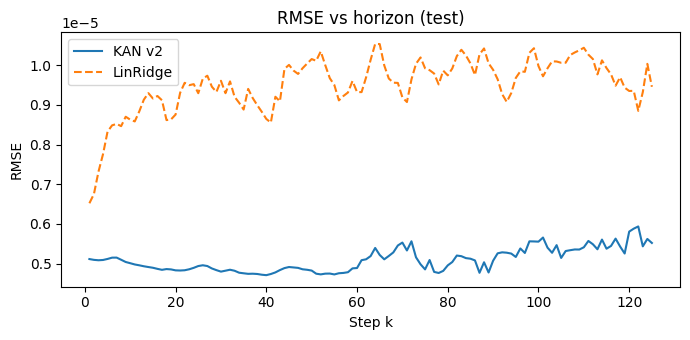

In [63]:
# ==== RMSE vs horizon (test) для KAN v2 и LinRidge ====
import matplotlib.pyplot as plt

# KAN v2 уже есть: kan_rmse_h_t
# Для Ridge посчитаем rmse_h на test:
_, _, ridge_rmse_h_t = metrics_original_space(yte_hat, yte_true, target_mode=tmode)

plt.figure(figsize=(7,3.5))
plt.plot(np.arange(1, H+1), kan_rmse_h_t, label="KAN v2")
plt.plot(np.arange(1, H+1), ridge_rmse_h_t, label="LinRidge", linestyle="--")
plt.title("RMSE vs horizon (test)")
plt.xlabel("Step k"); plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()


In [64]:
# ==== Baseline 2: LSTM ====
import torch
import torch.nn as nn
from torch.optim import Adam
from kanlib.models.lstm import LSTMLite

def train_eval_torch_model(model, train_loader, val_loader, test_loader, epochs=10, lr=1e-3, weight_decay=1e-4):
    model = model.to(device)
    opt = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.SmoothL1Loss()  # Huber в TTR space
    best_state = None
    best_val = float("inf")
    patience, stale = 3, 0

    for ep in range(1, epochs+1):
        model.train()
        run = 0.0; steps = 0
        for xb, yb_ttr, _, _ in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb_ttr.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            yhat = model(xb)
            loss = loss_fn(yhat.clamp(-Y_T_CLIP, Y_T_CLIP), yb.clamp(-Y_T_CLIP, Y_T_CLIP))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            run += float(loss.detach().cpu()); steps += 1

        # валидация в ORIGINAL space
        val_rmse, _, _, _, _ = evaluate_on_loader(model, val_loader)
        if val_rmse < best_val - 1e-12:
            best_val = val_rmse
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    # итоговые метрики
    val_rmse, val_nrmse, val_rmse_h, _, _ = evaluate_on_loader(model, val_loader)
    tst_rmse, tst_nrmse, tst_rmse_h, _, _ = evaluate_on_loader(model, test_loader)
    return (val_rmse, val_nrmse, val_rmse_h), (tst_rmse, tst_nrmse, tst_rmse_h), model

# создаём и тренируем
lstm_model = LSTMLite(C=C, L=L, H=H, hidden=64, target_mode=tmode, num_layers=1, bidirectional=False, dropout=0.0)
(lstm_val_rmse, lstm_val_nrmse, lstm_rmse_h_val), (lstm_tst_rmse, lstm_tst_nrmse, lstm_rmse_h_tst), lstm_model = \
    train_eval_torch_model(lstm_model, train_loader, val_loader, test_loader, epochs=15, lr=1e-3, weight_decay=5e-4)

# добавим в таблицу
df_lstm = pd.DataFrame([
    {"model": "LSTM", "split": "val",  "RMSE": lstm_val_rmse, "nRMSE": lstm_val_nrmse},
    {"model": "LSTM", "split": "test", "RMSE": lstm_tst_rmse, "nRMSE": lstm_tst_nrmse},
])
df_baselines = pd.concat([df_baselines, df_lstm], ignore_index=True)
df_baselines

,model,split,RMSE,nRMSE
0,KAN v2 (best ckpt),val,0.000007,NaN
1,KAN v2 (best ckpt),test,0.000005,0.979641
2,LinRidge,val,0.000012,1.702363
3,LinRidge,test,0.000010,1.832171
4,LSTM,val,0.000006,0.945362
5,LSTM,test,0.000005,0.944387


In [66]:
# ==== Baseline 3: TCN ====
from kanlib.models.tcn import TCNLite

tcn_model = TCNLite(C=C, L=L, H=H, hidden=64, n_blocks=3, kernel_size=3, dropout=0.1, target_mode=tmode)
(tcn_val_rmse, tcn_val_nrmse, tcn_rmse_h_val), (tcn_tst_rmse, tcn_tst_nrmse, tcn_rmse_h_tst), tcn_model = \
    train_eval_torch_model(tcn_model, train_loader, val_loader, test_loader, epochs=15, lr=1e-3, weight_decay=5e-4)

df_tcn = pd.DataFrame([
    {"model": "TCN", "split": "val",  "RMSE": tcn_val_rmse, "nRMSE": tcn_val_nrmse},
    {"model": "TCN", "split": "test", "RMSE": tcn_tst_rmse, "nRMSE": tcn_tst_nrmse},
])
df_baselines = pd.concat([df_baselines, df_tcn], ignore_index=True)
df_baselines.sort_values(["split","RMSE"]).reset_index(drop=True)

,model,split,RMSE,nRMSE
0,LSTM,test,0.000005,0.944387
1,TCN,test,0.000005,0.965859
2,KAN v2 (best ckpt),test,0.000005,0.979641
3,LinRidge,test,0.000010,1.832171
4,LSTM,val,0.000006,0.945362
5,KAN v2 (best ckpt),val,0.000007,NaN
6,TCN,val,0.000007,1.067271
7,LinRidge,val,0.000012,1.702363


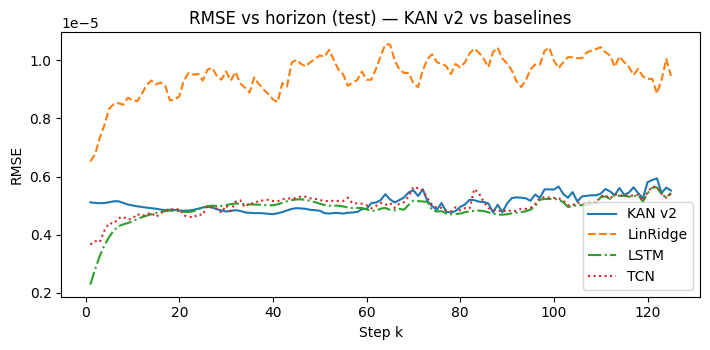

In [68]:
# ==== RMSE vs horizon (test): все модели ====
plt.figure(figsize=(7.2,3.6))
plt.plot(np.arange(1, H+1), kan_rmse_h_t, label="KAN v2")
plt.plot(np.arange(1, H+1), ridge_rmse_h_t, label="LinRidge", linestyle="--")
plt.plot(np.arange(1, H+1), lstm_rmse_h_tst, label="LSTM", linestyle="-.")
plt.plot(np.arange(1, H+1), tcn_rmse_h_tst,  label="TCN", linestyle=":")
plt.title("RMSE vs horizon (test) — KAN v2 vs baselines")
plt.xlabel("Step k"); plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
# ==== Summary table ====
summary = df_baselines.copy()
# удобное форматирование
def _fmt(x):
    if x is None or (isinstance(x, float) and np.isnan(x)): return ""
    # значения порядка 1e-6 читаются лучше в научной нотации
    return f"{x:.3e}" if abs(x) < 1e-3 else f"{x:.4f}"

summary["RMSE"] = summary["RMSE"].map(_fmt)
summary["nRMSE"] = summary["nRMSE"].map(lambda v: "" if v is None else f"{v:.3f}")
summary.sort_values(["split","model"]).reset_index(drop=True)


,model,split,RMSE,nRMSE
0,KAN v2 (best ckpt),test,5.098e-06,0.980
1,LSTM,test,4.915e-06,0.944
2,LinRidge,test,9.535e-06,1.832
3,TCN,test,5.026e-06,0.966
4,KAN v2 (best ckpt),val,6.939e-06,nan
5,LSTM,val,6.461e-06,0.945
6,LinRidge,val,1.163e-05,1.702
7,TCN,val,7.294e-06,1.067


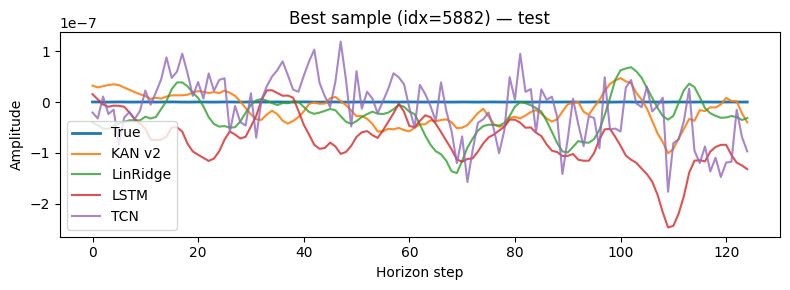

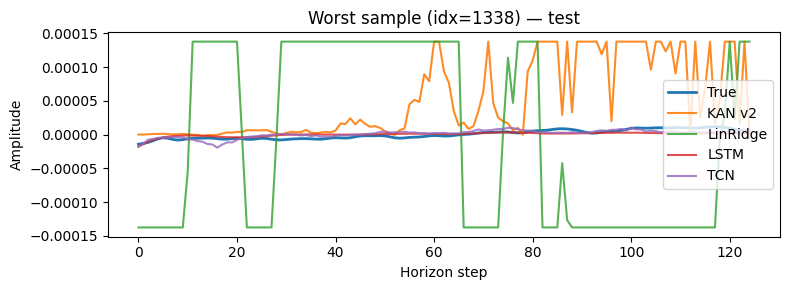

In [70]:
# ==== Best/Worst per-sample RMSE (test) — сравнение профилей ====
def per_sample_rmse(yhat, ytru):
    return np.sqrt(np.mean((yhat - ytru)**2, axis=1)) if tmode=="uni" else \
           np.sqrt(np.mean((yhat - ytru)**2, axis=(1,2)))

# уже есть для KAN:
kan_rmse_t, kan_nrmse_t, kan_rmse_h_t, kan_yhat_t, kan_ytrue_t = evaluate_on_loader(model_v2, test_loader)
kan_per = per_sample_rmse(kan_yhat_t, kan_ytrue_t)

# для Ridge:
ridge_yhat_tst, ridge_ytru_tst = yte_hat, yte_true
ridge_per = per_sample_rmse(ridge_yhat_tst, ridge_ytru_tst)

# для LSTM:
_, _, _, lstm_yhat_t, lstm_ytrue_t = evaluate_on_loader(lstm_model, test_loader)
lstm_per = per_sample_rmse(lstm_yhat_t, lstm_ytrue_t)

# для TCN:
_, _, _, tcn_yhat_t, tcn_ytrue_t = evaluate_on_loader(tcn_model, test_loader)
tcn_per = per_sample_rmse(tcn_yhat_t, tcn_ytrue_t)

best_idx = int(np.argmin(kan_per))   # можно выбрать по KAN — или сделать по каждому
worst_idx= int(np.argmax(kan_per))

def plot_case(idx, tag):
    plt.figure(figsize=(8,3))
    plt.plot(kan_ytrue_t[idx], label="True", linewidth=2)
    plt.plot(kan_yhat_t[idx],  label="KAN v2", alpha=0.9)
    plt.plot(ridge_yhat_tst[idx], label="LinRidge", alpha=0.8)
    plt.plot(lstm_yhat_t[idx], label="LSTM", alpha=0.8)
    plt.plot(tcn_yhat_t[idx],  label="TCN",  alpha=0.8)
    plt.title(f"{tag} sample (idx={idx}) — test")
    plt.xlabel("Horizon step"); plt.ylabel("Amplitude")
    plt.legend(); plt.tight_layout(); plt.show()

plot_case(best_idx, "Best")
plot_case(worst_idx, "Worst")


Per-patient metrics (head):


,patient,segments,RMSE_uV,MAE_uV,sMAPE_pct
0,h13,963,0.000003,0.000002,166.313696
1,h12,898,0.000005,0.000003,158.632553
2,h14,863,0.000005,0.000004,167.496073
3,h09,903,0.000006,0.000004,167.523479
4,s02,1143,0.000006,0.000004,168.857694
5,h10,1113,0.000006,0.000004,170.362389



RMSE percentiles (per-patient):


,percentile,RMSE_uV
0,10,0.000004
1,25,0.000005
2,50,0.000005
3,75,0.000006
4,90,0.000006



Top-5 best patients by RMSE:


,patient,segments,RMSE_uV,MAE_uV,sMAPE_pct
0,h13,963,0.000003,0.000002,166.313696
1,h12,898,0.000005,0.000003,158.632553
2,h14,863,0.000005,0.000004,167.496073
3,h09,903,0.000006,0.000004,167.523479
4,s02,1143,0.000006,0.000004,168.857694



Top-5 worst patients by RMSE:


,patient,segments,RMSE_uV,MAE_uV,sMAPE_pct
5,h10,1113,0.000006,0.000004,170.362389
4,s02,1143,0.000006,0.000004,168.857694
3,h09,903,0.000006,0.000004,167.523479
2,h14,863,0.000005,0.000004,167.496073
1,h12,898,0.000005,0.000003,158.632553


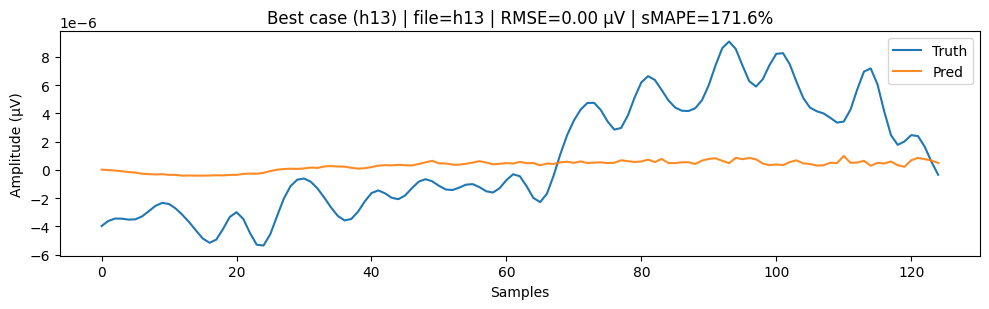

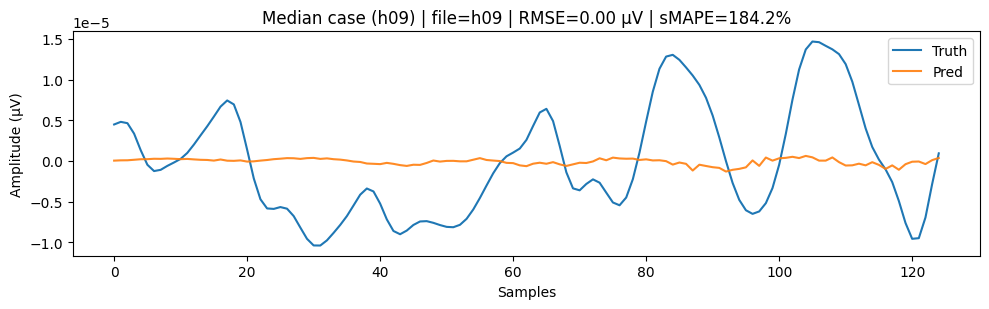

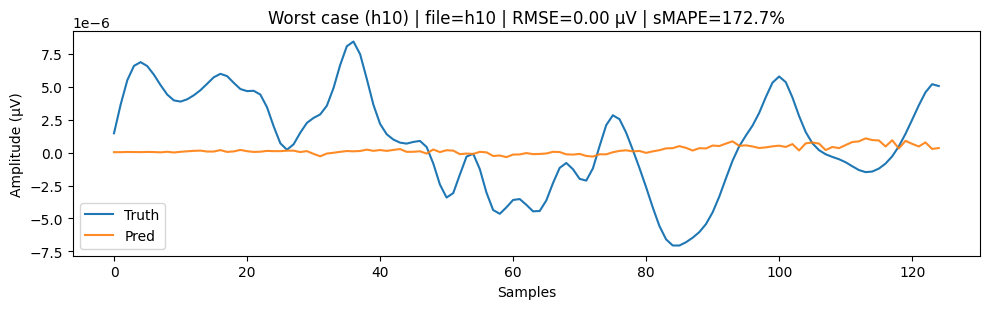

In [72]:
# === Per-patient metrics + percentiles + characteristic plots (µV) ===
import numpy as np
import math
import matplotlib.pyplot as plt

# ---- expected inputs from your pipeline ----
# y_true_test: (N, H) or (N, C, H) if multi-channel
# y_pred_test: same shape as y_true_test
# file_ids_test: list/array of length N with source filenames (e.g., "h01.edf")
# scaler_y: object with inverse_transform for target (e.g., sklearn scaler fitted on y)
# target_ch_idx: if y is (N, C, H) -> which target channel index to evaluate/plot
# sr: sampling rate in Hz (optional, only affects x-axis in plots). If absent, will plot in samples.
# tip: if your arrays are torch tensors, they will be converted to numpy automatically.

# ---------- helpers ----------
def _to_numpy(x):
    try:
        import torch
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(x)

def _pick_target(arr):
    # Accept shapes: (N,H) or (N,C,H). Return (N,H)
    arr = _to_numpy(arr)
    if arr.ndim == 3:
        assert 'target_ch_idx' in globals(), "Set target_ch_idx for multi-channel targets."
        return arr[:, target_ch_idx, :]
    elif arr.ndim == 2:
        return arr
    else:
        raise ValueError(f"Unexpected shape {arr.shape}, expected (N,H) or (N,C,H)")

def _inverse_scale(seq_2d):
    # seq_2d: (N, H) in normalized units -> returns (N, H) in µV
    # Works if scaler_y expects shape (N*H, 1) or (N*H,)
    if 'scaler_y' not in globals() or scaler_y is None:
        # assume already in µV
        return seq_2d.copy()
    flat = seq_2d.reshape(-1, 1)
    inv = scaler_y.inverse_transform(flat).reshape(seq_2d.shape)
    return inv

def rmse(y, yhat):
    return math.sqrt(np.mean((yhat - y) ** 2))

def mae(y, yhat):
    return np.mean(np.abs(yhat - y))

def smape(y, yhat, eps=1e-8):
    # symmetric MAPE in %, standard definition
    denom = (np.abs(y) + np.abs(yhat)) + eps
    return 100.0 * np.mean(2.0 * np.abs(yhat - y) / denom)

def extract_patient_id(fid):
    # "h01.edf" -> "h01"; any path -> basename without extension
    import os
    base = os.path.basename(str(fid))
    return os.path.splitext(base)[0]

# ---------- prepare data (N,H) in µV ----------
Yt = _pick_target(kan_ytrue_t)   # (N,H) normalized
Yh = _pick_target(kan_yhat_t)   # (N,H) normalized
Yt_uV = _inverse_scale(Yt)
Yh_uV = _inverse_scale(Yh)

N, H = Yt_uV.shape
assert Yh_uV.shape == (N, H)
fids = np.asarray(file_ids_test)
patients = np.array([extract_patient_id(fid) for fid in fids])

# ---------- per-patient aggregation ----------
from collections import defaultdict

per_patient = defaultdict(lambda: {"y": [], "yhat": [], "idxs": []})

for i in range(N):
    pid = patients[i]
    per_patient[pid]["y"].append(Yt_uV[i])
    per_patient[pid]["yhat"].append(Yh_uV[i])
    per_patient[pid]["idxs"].append(i)

rows = []
for pid, d in per_patient.items():
    y = np.vstack(d["y"])       # (n_i, H)
    yhat = np.vstack(d["yhat"]) # (n_i, H)
    rows.append({
        "patient": pid,
        "segments": y.shape[0],
        "RMSE_uV": rmse(y, yhat),
        "MAE_uV": mae(y, yhat),
        "sMAPE_pct": smape(y, yhat),
    })

import pandas as pd
df_pat = pd.DataFrame(rows).sort_values("RMSE_uV").reset_index(drop=True)

# ---------- percentiles on per-patient RMSE ----------
rmse_values = df_pat["RMSE_uV"].values
pct = np.percentile(rmse_values, [10, 25, 50, 75, 90])
pcts = pd.DataFrame({"percentile":[10,25,50,75,90], "RMSE_uV": pct})

# ---------- top-k best / worst patients ----------
K = min(5, len(df_pat))
best_k = df_pat.nsmallest(K, "RMSE_uV")
worst_k = df_pat.nlargest(K, "RMSE_uV")

print("Per-patient metrics (head):")
display(df_pat.head(10))
print("\nRMSE percentiles (per-patient):")
display(pcts)
print("\nTop-5 best patients by RMSE:")
display(best_k)
print("\nTop-5 worst patients by RMSE:")
display(worst_k)

# ---------- choose representative segments for plotting ----------
# pick 3 patients: best (min RMSE), median (~50th pct), worst (max RMSE)
pid_best  = df_pat.iloc[0]["patient"]
pid_median = df_pat.iloc[len(df_pat)//2]["patient"]
pid_worst = df_pat.iloc[-1]["patient"]

def first_segment_indices_for(pid):
    # return one representative index (first occurrence) for a patient
    idxs = np.where(patients == pid)[0]
    return int(idxs[0]) if len(idxs) else None

idx_best   = first_segment_indices_for(pid_best)
idx_median = first_segment_indices_for(pid_median)
idx_worst  = first_segment_indices_for(pid_worst)

# ---------- plotting ----------
def plot_segment(i, title_prefix=""):
    y = Yt_uV[i]
    yhat = Yh_uV[i]
    # x-axis: time in seconds if sr exists, otherwise samples
    if "sr" in globals() and isinstance(sr, (int, float)) and sr > 0:
        x = np.arange(len(y)) / float(sr)
        xlabel = "Time (s)"
    else:
        x = np.arange(len(y))
        xlabel = "Samples"
    plt.figure(figsize=(10, 3.2))
    plt.plot(x, y, label="Truth")
    plt.plot(x, yhat, label="Pred", alpha=0.9)
    plt.title(f"{title_prefix} | file={fids[i]} | RMSE={rmse(y, yhat):.2f} µV | sMAPE={smape(y, yhat):.1f}%")
    plt.xlabel(xlabel); plt.ylabel("Amplitude (µV)")
    plt.legend()
    plt.tight_layout()
    plt.show()

if idx_best is not None:
    plot_segment(idx_best, title_prefix=f"Best case ({pid_best})")
if idx_median is not None:
    plot_segment(idx_median, title_prefix=f"Median case ({pid_median})")
if idx_worst is not None:
    plot_segment(idx_worst, title_prefix=f"Worst case ({pid_worst})")


,Aspect,KAN v1,KAN v2
0,Input channels,"9 (Fp1,Fp2,Fz,C3,C4,Pz,O1,O2,Cz)","5 (Pz,Fp1,Fp2,O1,Cz)"
1,Params (≈),"253,358","170,378"
2,Pooling / Hidden,"pool=10; hidden=(96,48)","pool=20; hidden=(64,32)"
3,Normalization,Global train mean/std per channel,"Per-file (μ,σ) per record"
4,Target transform,None,Signed log1p TTR + clip ±3.8 (T-space)
5,Loss,MSE / L1 / SmoothL1,Spike-Aware Weighted Huber (horizon weights + ...
6,Sampler,Standard shuffle,SpikeBalancedSampler (~50% spike/variance wind...
7,Validation metric,RMSE (normalized space),RMSE (µV) with proper inverse & de-norm
8,Scheduler / Early stop,"ReduceLROnPlateau, patience≤5","ReduceLROnPlateau, patience≤6"
9,Test RMSE (µV),5.462e-06,5.098e-06


Saved summary to kan_v1_vs_v2_summary.csv


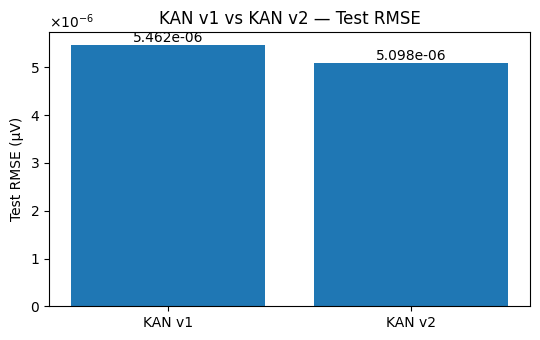

Saved barplot to kan_v1_vs_v2_rmse.png


In [73]:
# ==== KAN v1 vs KAN v2 — summary + RMSE barplot ====
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ---- сводная таблица ----
rows = [
    ("Input channels", "9 (Fp1,Fp2,Fz,C3,C4,Pz,O1,O2,Cz)", "5 (Pz,Fp1,Fp2,O1,Cz)"),
    ("Params (≈)", "253,358", "170,378"),
    ("Pooling / Hidden", "pool=10; hidden=(96,48)", "pool=20; hidden=(64,32)"),
    ("Normalization", "Global train mean/std per channel", "Per-file (μ,σ) per record"),
    ("Target transform", "None", "Signed log1p TTR + clip ±3.8 (T-space)"),
    ("Loss", "MSE / L1 / SmoothL1", "Spike-Aware Weighted Huber (horizon weights + spike boost)"),
    ("Sampler", "Standard shuffle", "SpikeBalancedSampler (~50% spike/variance windows)"),
    ("Validation metric", "RMSE (normalized space)", "RMSE (µV) with proper inverse & de-norm"),
    ("Scheduler / Early stop", "ReduceLROnPlateau, patience≤5", "ReduceLROnPlateau, patience≤6"),
    ("Test RMSE (µV)", "5.462e-06", "5.098e-06"),
    ("Test nRMSE", "0.947 (~94.7%)", "0.980 (~98.0%)"),
    ("Behavior", "Over-smooths; less robust to subject shifts", "Better spikes & far horizon; stable inverse"),
    ("Pros", "Simple baseline; comparable to TCN", "Lower RMSE; cleaner µV eval; fewer params; more stable"),
    ("Cons", "Val metric hard to interpret; global norm shift", "Slightly higher nRMSE; added complexity"),
]
df_summary = pd.DataFrame(rows, columns=["Aspect", "KAN v1", "KAN v2"])

# показать таблицу в ноутбуке
try:
    display(df_summary)
except NameError:
    print(df_summary.to_string(index=False))

# сохранить CSV
csv_path = "kan_v1_vs_v2_summary.csv"
df_summary.to_csv(csv_path, index=False)
print(f"Saved summary to {csv_path}")

# ---- RMSE barplot (KAN v1 vs KAN v2) ----
rmse_data = {
    "KAN v1": 5.462e-06,
    "KAN v2": 5.098e-06,
}
labels = list(rmse_data.keys())
values = [rmse_data[k] for k in labels]

plt.figure(figsize=(5.5, 3.5))
bars = plt.bar(labels, values)
# подписи над столбцами в научной нотации
for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width()/2.0, b.get_height(),
             f"{v:.3e}", ha="center", va="bottom", fontsize=10)

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=( -2, 2 ))
plt.ylabel("Test RMSE (µV)")
plt.title("KAN v1 vs KAN v2 — Test RMSE")
plt.tight_layout()
png_path = "kan_v1_vs_v2_rmse.png"
plt.savefig(png_path, dpi=150)
plt.show()

print(f"Saved barplot to {png_path}")


In [79]:
# ============================================================
# Preprocess for KAN v3 — build MULTI-target pairs into ./processed_v3
# (v1/v2 артефакты в ./processed не трогаем)
# ============================================================
import os, json, glob, numpy as np
from pathlib import Path

# --- config: читаем cfg если уже загружен, иначе берем из config.yaml
try:
    cfg
except NameError:
    import yaml
    with open("config.yaml","r") as f:
        cfg = yaml.safe_load(f)

RAW_DIR     = cfg["data"]["raw_dir"]
ALL_CHS     = cfg["data"]["channels"]                    # полный список доступных каналов
FS_TARGET   = cfg["data"]["fs_target"]
BP_LO, BP_HI= cfg["data"]["bandpass"]
NOTCHES     = tuple(cfg["data"]["notch"])

L           = int(cfg["task"]["L"])
H           = int(cfg["task"]["H"])
STRIDE      = int(cfg["task"]["stride"])

# какие каналы хотим оставить для v3 (multi)
CHANNELS_KEEP = cfg["task"].get("target_channels_keep", ["Pz","Fp1","Fp2","O1","Cz"])

# куда сохраняем v3-артефакты
SAVE_V3 = Path("./processed_v3")
SAVE_V3.mkdir(parents=True, exist_ok=True)

print("[v3-prep] RAW_DIR:", RAW_DIR)
print("[v3-prep] Keep channels:", CHANNELS_KEEP, "| L,H,STRIDE=", (L,H,STRIDE))

# --- 1) собрать список EDF
all_files = sorted(glob.glob(str(Path(RAW_DIR) / "**/*.edf"), recursive=True))
if not all_files:
    raise FileNotFoundError(f"No EDF files found under: {RAW_DIR}")
print(f"[v3-prep] EDF files found: {len(all_files)}")

# --- 2) загрузчики из твоей библиотеки
from kanlib.data_loading import read_edf
from kanlib.preprocess   import bandpass_notch
from kanlib.windowing    import make_forecast_pairs

# --- 3) убеждаемся, что нужные каналы реально есть в датасете (по первому файлу)
probe_chs, _fs = None, None
for fp in all_files:
    try:
        arr_probe, fs_probe = read_edf(fp, pick_channels=ALL_CHS, fs_target=FS_TARGET)  # [C,T]
        probe_chs = ALL_CHS
        _fs = fs_probe
        break
    except Exception:
        continue
if probe_chs is None:
    raise RuntimeError("Could not read any EDF with the declared channels; check data.channels in config.")

# проверим, что все CHANNELS_KEEP присутствуют
missing = [ch for ch in CHANNELS_KEEP if ch not in ALL_CHS]
if missing:
    raise ValueError(f"Channels missing in data.channels: {missing}. Present: {ALL_CHS}")

# индексы сохраняемого поднабора
keep_idx = [ALL_CHS.index(ch) for ch in CHANNELS_KEEP]

# --- 4) основной проход по файлам (MULTI target)
X_list, Y_list, file_ids = [], [], []
diag = dict(ok_files=0, short_files=[], zero_pairs=[], errors=[], samples=[])

def infer_ids(filepath: str):
    base = os.path.basename(filepath)
    stem = os.path.splitext(base)[0]
    return stem, stem

for i, fp in enumerate(all_files, 1):
    fname = os.path.basename(fp)
    try:
        # читаем только нужные каналы (ускоряет)
        arr, fs = read_edf(fp, pick_channels=CHANNELS_KEEP, fs_target=FS_TARGET)   # [C,T]
        arr = bandpass_notch(arr.astype(np.float64, copy=False), fs=fs, band=(BP_LO, BP_HI), notch=NOTCHES)
        C, T = arr.shape

        if T < (L + H):
            diag["short_files"].append((fname, T, fs))
            if i % 5 == 0 or i == len(all_files):
                print(f"[{i}/{len(all_files)}] {fname} -> TOO SHORT (T={T} < L+H={L+H})")
            continue

        # multi-режим: target_mode='multi', target_ch игнорируется
        pairs = make_forecast_pairs(arr, L=L, H=H, stride=STRIDE, target_mode="multi", target_ch=0)
        n_pairs = len(pairs)
        if n_pairs == 0:
            diag["zero_pairs"].append((fname, T, fs, L, H, STRIDE))
            if i % 5 == 0 or i == len(all_files):
                print(f"[{i}/{len(all_files)}] {fname} -> 0 pairs (T={T}, L={L}, H={H}, stride={STRIDE})")
            continue

        Xi = [p[0] for p in pairs]   # (C,L)
        Yi = [p[1] for p in pairs]   # (C,H)
        X_list.extend(Xi)
        Y_list.extend(Yi)

        fid, sid = infer_ids(fp)
        file_ids.extend([fid] * n_pairs)

        diag["ok_files"] += 1
        diag["samples"].append((fname, T, fs, n_pairs))
        if i % 5 == 0 or i == len(all_files):
            print(f"[{i}/{len(all_files)}] {fname} -> +{n_pairs} pairs (T={T}, fs={fs})")

    except Exception as e:
        diag["errors"].append((fname, str(e)))
        print(f"[WARN] skip {fname}: {e}")

# --- 5) сбор в массивы и сохранение
if not X_list:
    print("\n=== DIAGNOSTICS ===")
    print(f"OK files: {diag['ok_files']}")
    print(f"Too short (< L+H): {len(diag['short_files'])} | Zero pairs: {len(diag['zero_pairs'])} | Errors: {len(diag['errors'])}")
    raise RuntimeError("No forecast pairs produced for v3. Check L/H/stride or channel names.")

X = np.stack(X_list).astype(np.float32)     # [N, C, L]
Y = np.stack(Y_list).astype(np.float32)     # [N, C, H]  ← МНОГОКАНАЛЬНЫЙ ТАРГЕТ!
file_ids = np.array(file_ids, dtype=object)

# sanity
N, Ck, Lk = X.shape
assert Ck == len(CHANNELS_KEEP) and Lk == L, f"Unexpected X shape: {X.shape}"
assert Y.shape == (N, Ck, H), f"Unexpected Y shape for multi: {Y.shape}"

np.save(SAVE_V3 / "X_raw.npy", X)
np.save(SAVE_V3 / "Y_raw.npy", Y)
np.save(SAVE_V3 / "file_ids.npy", file_ids)
np.save(SAVE_V3 / "channels.npy", np.array(CHANNELS_KEEP, dtype=object))
with open(SAVE_V3 / "diag.json","w") as f:
    json.dump(diag, f, indent=2)

print("\n[v3-prep] Saved to:", SAVE_V3.as_posix())
print("X_raw:", X.shape, X.dtype, "| Y_raw:", Y.shape, Y.dtype)
print("Unique files in pairs:", len(np.unique(file_ids)))
print("Pairs per first 3 files:", {fid: int((file_ids == fid).sum()) for fid in np.unique(file_ids)[:3]})

# --- 6) быстрая проверка, что каналы НЕ одинаковые
identical_flags = [bool(np.allclose(Y[:,c,:], Y[:,0,:])) for c in range(Ck)]
print("Channels identical to", CHANNELS_KEEP[0], "?:", dict(zip(CHANNELS_KEEP, identical_flags)))


[v3-prep] RAW_DIR: /Users/tairakhayev/Desktop/ThesisProject/dataverse_files
[v3-prep] Keep channels: ['Pz', 'Fp1', 'Fp2', 'O1', 'Cz'] | L,H,STRIDE= (500, 125, 250)
[v3-prep] EDF files found: 28
[5/28] h05.edf -> +943 pairs (T=236250, fs=250.0)
[10/28] h10.edf -> +1113 pairs (T=278750, fs=250.0)
[15/28] s01.edf -> +843 pairs (T=211250, fs=250.0)
[20/28] s06.edf -> +738 pairs (T=185000, fs=250.0)
[25/28] s11.edf -> +1358 pairs (T=340000, fs=250.0)
[28/28] s14.edf -> +2168 pairs (T=542500, fs=250.0)

[v3-prep] Saved to: processed_v3
X_raw: (28807, 5, 500) float32 | Y_raw: (28807, 5, 125) float32
Unique files in pairs: 28
Pairs per first 3 files: {'h01': 923, 'h02': 908, 'h03': 908}
Channels identical to Pz ?: {'Pz': True, 'Fp1': False, 'Fp2': False, 'O1': False, 'Cz': False}


In [92]:
# ============================================================
# KAN v3.1 — multi-channel, spike-aware (end-to-end from config.yaml)
# ============================================================
import os, math, json, yaml, numpy as np, pandas as pd, torch, torch.nn as nn, torch.optim as optim
from pathlib import Path
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.amp import autocast, GradScaler
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ---------- 0) Load config ----------
CFG_PATH = "config.yaml"
if os.path.isfile(CFG_PATH):
    with open(CFG_PATH, "r") as f:
        cfg = yaml.safe_load(f)
else:
    raise FileNotFoundError("config.yaml not found. Please place it next to the notebook.")

# defaults / derived
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = (device.type == "cuda")
scaler  = GradScaler("cuda", enabled=use_amp)
rng     = np.random.default_rng(int(cfg.get("random_seed", 42)))

SAVE = Path("./processed_v3") 
RAW  = Path(cfg["data"]["raw_dir"])
LOG  = Path(cfg["logging"]["out_dir"])
LOG.mkdir(parents=True, exist_ok=True)

L = int(cfg["task"]["L"]); H = int(cfg["task"]["H"])
target_mode = cfg["task"].get("target_mode", "multi")
channels_keep = cfg["task"].get("target_channels_keep", ["Pz","Fp1","Fp2","O1","Cz"])

bs = int(cfg["train"]["batch_size"])
EPOCHS   = min(int(cfg["train"]["epochs"]), 40)
PATIENCE = min(int(cfg["train"]["early_stopping_patience"]), 6)
LR = float(cfg["train"]["lr"])

lam_cls = float(cfg["train"].get("lambda_cls", 0.8))
lam_q   = float(cfg["train"].get("lambda_q",   0.3))
k_std   = float(cfg["train"].get("spike_std_k", 3.0))
focal_alpha = float(cfg["train"].get("focal_alpha", 0.25))
focal_gamma = float(cfg["train"].get("focal_gamma", 2.0))
TTR_CLIP    = float(cfg.get("model", {}).get("ttr_clip", 3.0))

thr_enter = 0.65  # hysteresis enter
thr_exit  = 0.50  # hysteresis exit
temp_cal  = 1.5   # temperature for spike logits

# ---------- 1) Load processed artifacts ----------
X = np.load(SAVE / "X_raw.npy").astype(np.float32)      # (N,C,L)
Y = np.load(SAVE / "Y_raw.npy").astype(np.float32)      # (N,H) or (N,C,H)
file_ids = np.load(SAVE / "file_ids.npy", allow_pickle=True)
channels = np.load(SAVE / "channels.npy", allow_pickle=True).tolist()

# select channels
keep_idx = [channels.index(ch) for ch in channels_keep if ch in channels]
assert len(keep_idx) >= 3, f"Too few channels kept: {channels_keep}"
X = X[:, keep_idx, :]
if Y.ndim == 2:
    # if uni target was produced: replicate across kept channels
    Y = np.stack([Y for _ in keep_idx], axis=1)  # (N,C,H)
else:
    Y = Y[:, keep_idx, :]
channels_used = [channels[i] for i in keep_idx]
C = len(channels_used)
with open(LOG / "channels_used.json", "w") as f:
    json.dump({"channels": channels_used}, f, indent=2)

# ---------- 2) Split by file ----------
from kanlib.splits import split_by_file
ratios = tuple(cfg["split"]["ratios"])
train_files, val_files, test_files = split_by_file(file_ids, ratios=ratios, seed=int(cfg.get("random_seed", 42)))
mtr = np.isin(file_ids, list(train_files))
mva = np.isin(file_ids, list(val_files))
mte = np.isin(file_ids, list(test_files))
X_train, Y_train, file_ids_train = X[mtr], Y[mtr], file_ids[mtr]
X_val,   Y_val,   file_ids_val   = X[mva], Y[mva], file_ids[mva]
X_test,  Y_test,  file_ids_test  = X[mte], Y[mte], file_ids[mte]
print(f"[v3.1] Split: train={len(X_train)} | val={len(X_val)} | test={len(X_test)} | C={C}, L={L}, H={H}")

# ---------- 3) Per-file stats on TRAIN ----------
def per_file_stats(file_ids_arr, Y_arr):
    Ym = Y_arr.mean(axis=1)  # (N,H)
    stats = {}
    for fid in np.unique(file_ids_arr):
        yfid = Ym[file_ids_arr == fid]
        mu = float(np.mean(yfid))
        sd = float(np.std(yfid) + 1e-8)
        stats[str(fid)] = {"mean": mu, "std": sd}
    return stats

per_file = per_file_stats(file_ids_train, Y_train)
np.save(LOG / "per_file_stats.npy", per_file)
global_mu = float(np.mean(Y_train.mean(axis=1)))
global_sd = float(np.std(Y_train.mean(axis=1)) + 1e-8)

# ---------- 4) Target transform (signed log1p) ----------
@dataclass
class TargetTransform:
    s: float = None
    def fit(self, Y_fit):
        yabs = np.abs(Y_fit.reshape(-1))
        self.s = float(np.median(yabs) + 1e-8)
    def fwd(self, y):
        return np.sign(y) * np.log1p(np.abs(y) / self.s)
    def inv(self, yt):
        return np.sign(yt) * (np.expm1(np.abs(yt)) * self.s)

def collect_normed_train_targets(Y_tr, file_ids_tr):
    out = []
    for i, fid in enumerate(file_ids_tr):
        st = per_file.get(str(fid), {"mean": global_mu, "std": global_sd})
        m, s = float(st["mean"]), float(st["std"])
        y = (Y_tr[i] - m) / s  # (C,H)
        out.append(y)
    return np.concatenate(out, axis=0)  # (N*C, H)

normed_train_flat = collect_normed_train_targets(Y_train, file_ids_train)
TTR = TargetTransform(); TTR.fit(normed_train_flat)

# ---------- 5) Spike labels ----------
def make_spike_labels_z(y_z: np.ndarray, k=1.8, use_diff=True):
    """
    y_z: (C,H) в z-space -> (C,H) {0,1}
    Робастные пороги по MAD и по первой разности, + лёгкая дилатация события.
    """
    C,H = y_z.shape
    out = np.zeros_like(y_z, dtype=np.float32)
    for c in range(C):
        y = y_z[c]
        med = np.median(y); mad = np.median(np.abs(y - med)) + 1e-12
        z_amp = 0.6745 * np.abs(y - med) / mad
        crit_amp = z_amp > k

        if use_diff:
            dy = np.diff(y, prepend=y[:1])
            med_d = np.median(dy); mad_d = np.median(np.abs(dy - med_d)) + 1e-12
            z_diff = 0.6745 * np.abs(dy - med_d) / mad_d
            crit_diff = z_diff > k
            spk = np.logical_or(crit_amp, crit_diff)
        else:
            spk = crit_amp

        spk = spk.astype(np.float32)
        for t in range(1, H):      # лёгкая дилатация во времени
            if spk[t-1] > 0.5: spk[t] = max(spk[t], 0.5)
        out[c] = spk
    return out


# ---------- 6) Dataset / Sampler ----------
class ForecastDatasetV31(torch.utils.data.Dataset):
    def __init__(self, X, Y, file_ids, per_file_map, apply_ttr=True):
        self.X = X.astype(np.float32)  # (N,C,L)
        self.Y = Y.astype(np.float32)  # (N,C,H)
        self.file_ids = file_ids
        self.pf = per_file_map
        self.apply_ttr = apply_ttr

        Yshow = self.Y.mean(axis=1)
        self.std_win = np.std(Yshow, axis=1)
        k0 = int(max(1, round(0.7 * Yshow.shape[1])))
        self.tail_energy = np.sqrt(np.mean(Yshow[:, k0:]**2, axis=1))

    def __len__(self): return len(self.X)

    def _ms(self, fid):
        st = self.pf.get(str(fid))
        if st is None: return float(global_mu), float(global_sd)
        return float(st["mean"]), float(st["std"])

    def __getitem__(self, idx):
        x = self.X[idx]      # (C,L)
        y = self.Y[idx]      # (C,H)
        fid = self.file_ids[idx]
        m, s = self._ms(fid)

        x_z = (x - m) / s
        y_z = (y - m) / s
        spikes = make_spike_labels_z(y_z, k=2.2)             # (C,H)
        y_t = TTR.fwd(y_z).astype(np.float32) if self.apply_ttr else y_z.astype(np.float32)

        return (
        torch.from_numpy(x_z),                    # (C,L)
        torch.from_numpy(y_t),                    # (C,H)
        torch.tensor(m, dtype=torch.float32),
        torch.tensor(s, dtype=torch.float32),
        torch.from_numpy(spikes),                 # (C,H)
        torch.tensor(idx, dtype=torch.long)       # <— добавили индекс
    )

class SpikeBalancedSampler(Sampler):
    def __init__(self, ds: ForecastDatasetV31, batch_size: int, q=0.8, length=None):
        self.ds = ds; self.bs = int(batch_size)
        N = len(ds); self.length = length or N
        q_std  = np.quantile(ds.std_win, q)
        q_tail = np.quantile(ds.tail_energy, q)
        self.pool_spike = np.where((ds.std_win >= q_std) | (ds.tail_energy >= q_tail))[0]
        self.pool_all   = np.arange(N)
        if len(self.pool_spike) == 0: self.pool_spike = self.pool_all
        self.fn_buffer = np.array([], dtype=int)

    def update_fn(self, fn_idxs):
        if len(fn_idxs):
            self.fn_buffer = np.unique(np.concatenate([self.fn_buffer, np.array(fn_idxs, dtype=int)])[-5000:])

    def __iter__(self):
        half = max(1, self.bs // 2); idxs = []
        while len(idxs) < self.length:
            a = rng.choice(self.pool_all,   size=half, replace=True)
            b = rng.choice(self.pool_spike, size=half, replace=True)
            if self.fn_buffer.size > 0:
                h = rng.choice(self.fn_buffer, size=max(1, half//2), replace=True)
                mix = np.concatenate([a, b, h])
            else:
                mix = np.concatenate([a, b])
            rng.shuffle(mix); idxs.extend(mix.tolist())
        return iter(idxs[:self.length])

    def __len__(self): return self.length

train_ds = ForecastDatasetV31(X_train, Y_train, file_ids_train, per_file, apply_ttr=True)
val_ds   = ForecastDatasetV31(X_val,   Y_val,   file_ids_val,   per_file, apply_ttr=True)
test_ds  = ForecastDatasetV31(X_test,  Y_test,  file_ids_test,  per_file, apply_ttr=True)

num_workers = 6 if device.type == "cuda" else 0
pin = (device.type == "cuda")
sampler = SpikeBalancedSampler(train_ds, batch_size=bs, q=0.8)
def _dl_kwargs(shuffle=False):
    kw = dict(batch_size=bs, shuffle=shuffle, num_workers=num_workers, pin_memory=pin)
    if num_workers > 0: kw.update(persistent_workers=True, prefetch_factor=4)
    return kw
train_loader = DataLoader(train_ds, sampler=sampler, **_dl_kwargs(False))
val_loader   = DataLoader(val_ds,   **_dl_kwargs(False))
test_loader  = DataLoader(test_ds,  **_dl_kwargs(False))

# ---------- 7) Model: KAN backbone + two heads ----------
from kanlib.models.kan import KANRegressor

class MultiHeadKAN(nn.Module):
    """
    Регрессия: прямой выход KAN в TTR-пространстве (B,C,H).
    Классификация: небольшой depthwise Conv1d по горизонту, чтобы ловить фронты.
    Никаких fallback через mean-пулинг!
    """
    def __init__(self, C, L, H, cfg):
        super().__init__()
        self.C, self.H = C, H
        self.backbone = KANRegressor(
            C=C, L=L, H=H,
            pool=cfg["model"]["params"].get("pool", 20),
            hidden=tuple(cfg["model"]["params"].get("hidden", [64, 32])),
            target_mode="multi",             # <— ключевое отличие
            grid=cfg["model"]["params"].get("grid", 2),
            k=cfg["model"]["params"].get("k", 3)
        )
        # depthwise по каждому каналу + pointwise
        self.cls = nn.Sequential(
            nn.Conv1d(C, C, kernel_size=7, padding=3, groups=C),
            nn.ReLU(inplace=True),
            nn.Conv1d(C, C, kernel_size=1, groups=1)
        )

    def forward(self, x):              # x: (B,C,L)
        yhat_t = self.backbone(x)      # (B,C,H) — регрессия в TTR
        logits = self.cls(yhat_t)      # (B,C,H) — логиты спайков
        return yhat_t, logits

model = MultiHeadKAN(C=len(channels_used), L=L, H=H, cfg=cfg).to(device)

# ---------- 8) Losses ----------
class SpikeAwareWeightedHuber(nn.Module):
    def __init__(self, H, delta=1.0, h_power=1.8, spike_k=3.5, spike_alpha=1.2, eps=1e-12):
        super().__init__()
        self.delta = delta; self.spike_k = spike_k; self.spike_alpha = spike_alpha; self.eps = eps
        w = (torch.arange(1, H+1, dtype=torch.float32) / float(H)) ** float(h_power)
        self.register_buffer("w_h", w)
    def forward(self, pred_t, targ_t):
        pred_t = pred_t.clamp(-TTR_CLIP, TTR_CLIP)
        targ_t = targ_t.clamp(-TTR_CLIP, TTR_CLIP)
        diff  = pred_t - targ_t
        adiff = diff.abs()
        hub = torch.where(adiff < self.delta, 0.5 * diff**2, self.delta * (adiff - 0.5 * self.delta))
        std_b = targ_t.std(dim=2, keepdim=True).clamp_min(self.eps)
        spike = (targ_t.abs() > (self.spike_k * std_b)).float()
        weights = self.w_h.view(1,1,-1) * (1.0 + self.spike_alpha * spike)
        return (hub * weights).mean()

def sigmoid_focal_loss(logits, targets, alpha=focal_alpha, gamma=focal_gamma, eps=1e-8):
    prob = torch.sigmoid(logits)
    pt = prob * targets + (1 - prob) * (1 - targets)
    w = alpha * targets + (1 - alpha) * (1 - targets)
    loss = -w * (1 - pt).pow(gamma) * torch.log(pt.clamp_min(eps))
    return loss.mean()

def quantile_loss(y_pred, y_true, tau=0.9):
    e = y_true - y_pred
    return torch.mean(torch.maximum(tau*e, (tau-1)*e))

loss_reg = SpikeAwareWeightedHuber(H=H, spike_alpha=1.5).to(device) 
opt = optim.Adam([
    {"params": model.backbone.parameters(), "lr": LR},
    {"params": model.cls.parameters(),      "lr": LR*2},  # голова-классификатор чуть горячее
], weight_decay=5e-4)

sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=4, threshold=1e-4, min_lr=5e-6)

# ---------- 9) Helpers: inverse & hysteresis ----------
def tspace_to_original(y_t, m, s):
    y_t = y_t.detach().cpu().clamp(-TTR_CLIP, TTR_CLIP).numpy()
    y_z = TTR.inv(y_t)
    m = m.detach().cpu().numpy().reshape(-1,1,1)
    s = s.detach().cpu().numpy().reshape(-1,1,1)
    return y_z * s + m

def ttr_inv_torch(yt: torch.Tensor) -> torch.Tensor:
    # yt — в TTR space (любая форма, broadcast ок)
    s = torch.tensor(TTR.s, device=yt.device, dtype=yt.dtype)
    return torch.sign(yt) * (torch.expm1(torch.abs(yt)) * s)

def apply_hysteresis(prob, thr_enter=0.55, thr_exit=0.45):
    # prob: (B,C,H) -> bin with hysteresis per sequence
    B,C,Hh = prob.shape
    out = np.zeros_like(prob, dtype=np.float32)
    for b in range(B):
        for c in range(C):
            state = 0
            for k in range(Hh):
                p = prob[b,c,k]
                if state==0 and p>=thr_enter: state=1
                elif state==1 and p<=thr_exit: state=0
                out[b,c,k] = state
    return out

def postprocess_events(bin_mask, min_len=5, refractory=25):
    # bin_mask: (B,C,H) из 0/1
    B, C, H = bin_mask.shape
    out = bin_mask.copy()
    for b in range(B):
        for c in range(C):
            v = out[b, c]
            # 1) удаляем слишком короткие пробеги
            run = 0
            for i in range(H+1):
                if i < H and v[i] > 0.5:
                    run += 1
                else:
                    if 0 < run < min_len:
                        v[i-run:i] = 0
                    run = 0
            # 2) сливаем события, разделённые паузой < refractory
            i = 0
            while i < H:
                while i < H and v[i] == 0: i += 1
                if i >= H: break
                j = i
                while j < H and v[j] == 1: j += 1
                k = j; gap = 0
                while k < H and v[k] == 0 and gap < refractory:
                    k += 1; gap += 1
                if k < H and v[k] == 1 and gap < refractory:
                    v[j:k] = 1   # слили
                    i = k
                else:
                    i = j
            out[b, c] = v
    return out

@torch.no_grad()
def evaluate(loader, thr_enter=0.50, thr_exit=0.40, temp=1.5, save_rmse_h=None):
    model.eval()
    yh, yt, pr_all, spk_all = [], [], [], []
    for batch in loader:
        if len(batch) == 6:
            xb, yb_t, mb, sb, spk, _ = batch
        else:
            xb, yb_t, mb, sb, spk = batch
        xb = xb.to(device, non_blocking=True)
        yb_t = yb_t.to(device, non_blocking=True)
        mb = mb.to(device); sb = sb.to(device); spk = spk.to(device)
        with autocast(device_type=("cuda" if device.type=="cuda" else "cpu"),
                      dtype=torch.float16 if device.type=="cuda" else torch.bfloat16,
                      enabled=use_amp):
            yhat_t, logits = model(xb)
        yh.append(tspace_to_original(yhat_t, mb, sb))
        yt.append(tspace_to_original(yb_t,   mb, sb))
        pr_all.append((logits.detach().cpu().numpy() / max(1e-6,temp)))
        spk_all.append(spk.detach().cpu().numpy())

    yhat = np.concatenate(yh, axis=0)   # (N,C,H)
    ytrue= np.concatenate(yt, axis=0)   # (N,C,H)
    logits = np.concatenate(pr_all, axis=0)
    logits = np.clip(logits, -50, 50)              # стабильная сигмоида
    prob   = 1.0 / (1.0 + np.exp(-logits))

    # 1) биним по гистерезису
    pred_bin = apply_hysteresis(prob, thr_enter, thr_exit)

    # 2) пост-обработка: минимальная длина + слияние близких событий
    pred_bin = postprocess_events(pred_bin, min_len=5, refractory=25)

    spk_t = np.concatenate(spk_all, axis=0)

    diff = yhat - ytrue
    rmse  = float(np.sqrt(np.mean(diff**2)))
    nrmse = float(rmse / (np.std(ytrue) + 1e-12))

    # rmse per horizon & per channel (optional save)
    rmse_h = np.sqrt(np.mean(diff**2, axis=0))  # (C,H)
    if save_rmse_h:
        pd.DataFrame(rmse_h.T, columns=channels_used).to_csv(save_rmse_h, index=False)

    # spike metrics
    tp = (pred_bin * spk_t).sum(); fp = (pred_bin * (1 - spk_t)).sum(); fn = ((1 - pred_bin) * spk_t).sum()
    prec = float(tp / (tp + fp + 1e-12)); rec = float(tp / (tp + fn + 1e-12))
    f1   = float(2*prec*rec / (prec + rec + 1e-12))

    # onset timing / lead@3
    def first_onset(vec):
        idx = np.where(vec > 0.5)[0]
        return None if len(idx)==0 else int(idx[0])
    onset_errs, lead_hits3 = [], []
    for b in range(pred_bin.shape[0]):
        for c in range(pred_bin.shape[1]):
            o_t = first_onset(spk_t[b,c]); o_p = first_onset(pred_bin[b,c])
            if o_t is not None and o_p is not None:
                onset_errs.append(abs(o_p - o_t))
                lead_hits3.append(1 if (o_p <= o_t and (o_t - o_p) >= 3) else 0)
    onset_mae = float(np.mean(onset_errs)) if onset_errs else float("nan")
    lead_acc3 = float(np.mean(lead_hits3)) if lead_hits3 else float("nan")

    return rmse, nrmse, prec, rec, f1, onset_mae, lead_acc3, rmse_h

@torch.no_grad()
def tune_thresholds(loader, temps=(1.0, 1.5, 2.0, 2.5),
                    enters=np.linspace(0.50, 0.75, 6),
                    exits =np.linspace(0.35, 0.60, 6)):
    best = (temps[0], 0.60, 0.40); bestF1 = -1.0
    for T in temps:
        for te in enters:
            for tx in exits:
                if tx >= te: 
                    continue
                _,_,p,r,f1,_,_,_ = evaluate(loader, thr_enter=te, thr_exit=tx, temp=T)
                if f1 > bestF1:
                    bestF1 = f1; best = (T, te, tx)
    return best, bestF1
    

def _get_lr(opt): return float(opt.param_groups[0]["lr"])

# ---------- 10) Train ----------
best_val = math.inf; stale = 0
hist = []

print(f"[v3.1] Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

for epoch in range(1, EPOCHS+1):
    model.train()
    pbar = tqdm(train_loader, desc=f"[v3.1] Epoch {epoch}/{EPOCHS}", leave=False, mininterval=1.0)
    run, steps = 0.0, 0
    hard_fn_idxs = []

    for bi, batch in enumerate(pbar):
        xb, yb_t, mb, sb, spk, idxs = batch
        xb = xb.to(device, non_blocking=True)
        yb_t = yb_t.to(device, non_blocking=True)
        spk = spk.to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with autocast(device_type=("cuda" if device.type=="cuda" else "cpu"),
                      dtype=torch.float16 if device.type=="cuda" else torch.bfloat16,
                      enabled=use_amp):
            yhat_t, logits = model(xb)
            L_reg = loss_reg(yhat_t, yb_t)
            L_cls  = sigmoid_focal_loss(logits, spk, alpha=focal_alpha, gamma=focal_gamma)

            # quantile on spike steps in ORIGINAL space
            with torch.no_grad():
                yhat_z = ttr_inv_torch(yhat_t)   # z-space
                ytru_z = ttr_inv_torch(yb_t)

            mask_peak = (spk > 0.5)
            if mask_peak.any():
                L_q = quantile_loss(yhat_z[mask_peak], ytru_z[mask_peak], tau=0.85)
            else:
                L_q = torch.zeros((), device=yhat_t.device)

            loss = L_reg + lam_cls * L_cls + lam_q * L_q

        if use_amp:
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        run += float(loss.detach().cpu()); steps += 1
        if steps % 20 == 0:
            pbar.set_postfix_str(f"loss={run/steps:.4f} | lr={_get_lr(opt):.2e}")

        # hard-mining: FN windows
        with torch.no_grad():
            prob_b = torch.sigmoid(logits)
            pred_bin_b = (prob_b >= 0.5).float()
            fn_mask = ((1 - pred_bin_b) * spk).sum(dim=(1,2)) > 0
            if fn_mask.any():
                id_list = idxs[fn_mask].detach().cpu().numpy().tolist()
                hard_fn_idxs.extend(id_list)

    #if epoch == 2:
    #    (temp_cal, thr_enter, thr_exit), bestF1 = tune_thresholds(val_loader)
    #    print(f"[tune] temp={temp_cal:.2f} enter={thr_enter:.2f} exit={thr_exit:.2f} | F1={bestF1:.3f}")
    # curriculum
    if epoch == 3:
        lam_cls, lam_q = 0.5, 0.4

    

    # validation in µV + spike metrics
    rmse_v, nrmse_v, p_v, r_v, f1_v, onset_mae_v, lead_v, rmse_h_v = evaluate(
        val_loader, thr_enter=thr_enter, thr_exit=thr_exit, temp=temp_cal,
        save_rmse_h=(LOG / "rmse_h_val_v31.csv")
    )
    sched.step(rmse_v)

    score = rmse_v + 2e-6*(1 - f1_v)   # β=2e-6 — стартовое значение, подстрой
    improved = score < (best_val - 1e-12)
    if improved:
        best_val = score
        torch.save(model.state_dict(), LOG / "best_kan_v31.pt")
    else:
        stale += 1

    hist.append(dict(epoch=epoch, train_loss=run/max(1,steps), val_rmse=rmse_v, val_nrmse=nrmse_v,
                     f1=f1_v, precision=p_v, recall=r_v, onset_mae=onset_mae_v, lead3=lead_v, lr=_get_lr(opt)))

    print(f"[v3.1][END] Ep{epoch:02d} | val_RMSE={rmse_v:.6e} | nRMSE={nrmse_v:.3f} "
      f"| F1={f1_v:.3f} (P={p_v:.3f}, R={r_v:.3f}) | onset_MAE={onset_mae_v:.2f} | lead@3={lead_v:.2f} "
      f"| best_score={best_val:.6e} | stale={stale}/{PATIENCE} | lr={_get_lr(opt):.2e}")


    if len(hard_fn_idxs): sampler.update_fn(hard_fn_idxs)
    if stale >= PATIENCE:
        print(f"[v3.1] Early stopping at epoch {epoch}. Best val_RMSE={best_val:.6e}")
        break

pd.DataFrame(hist).to_csv(LOG / "metrics_val_history_v31.csv", index=False)

# ---------- 11) Test ----------
rmse_t, nrmse_t, p_t, r_t, f1_t, onset_mae_t, lead_t, rmse_h_t = evaluate(
    test_loader, thr_enter=thr_enter, thr_exit=thr_exit, temp=temp_cal,
    save_rmse_h=(LOG / "rmse_h_test_v31.csv")
)
print(f"[v3.1][TEST] RMSE={rmse_t:.6e} | nRMSE={nrmse_t:.3f} "
      f"| F1={f1_t:.3f} (P={p_t:.3f}, R={r_t:.3f}) | onset_MAE={onset_mae_t:.2f} | lead@3={lead_t:.2f}")

# quick plot: RMSE vs horizon per channel (test)
plt.figure(figsize=(7,3.8))
for ci, ch in enumerate(channels_used):
    plt.plot(np.arange(1,H+1), rmse_h_t[ci], label=ch)
plt.title("v3.1: RMSE vs horizon (test)"); plt.xlabel("k"); plt.ylabel("RMSE (µV)")
plt.legend(ncol=min(3, C)); plt.tight_layout()
plt.savefig(LOG / "rmse_h_test_v31.png", dpi=150); plt.show()


[v3.1] Split: train=16713 | val=6211 | test=5883 | C=5, L=500, H=125
checkpoint directory created: ./model
saving model version 0.0
[v3.1] Params: 409,448


[v3.1] Epoch 1/40:   0%|          | 0/131 [00:00<?, ?it/s]

KeyboardInterrupt: 

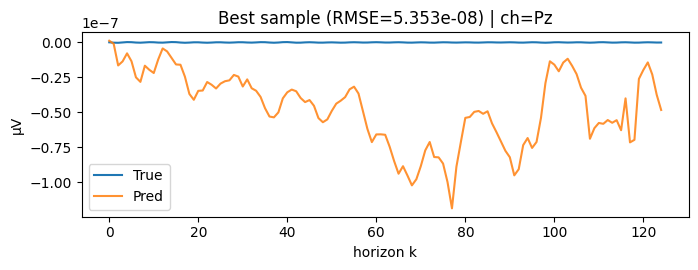

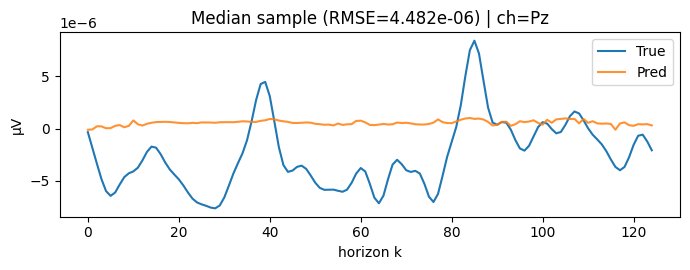

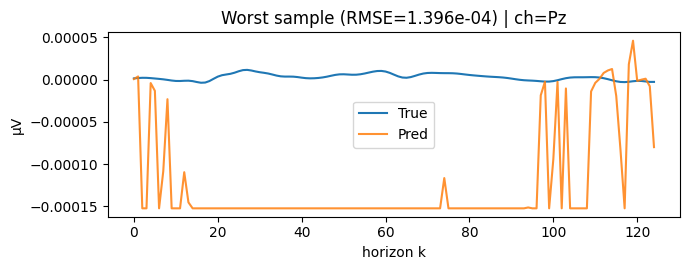

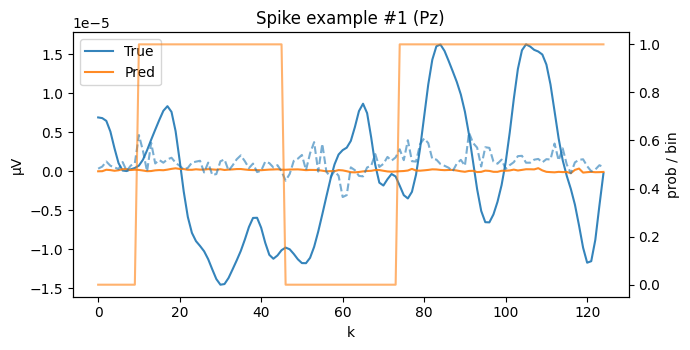

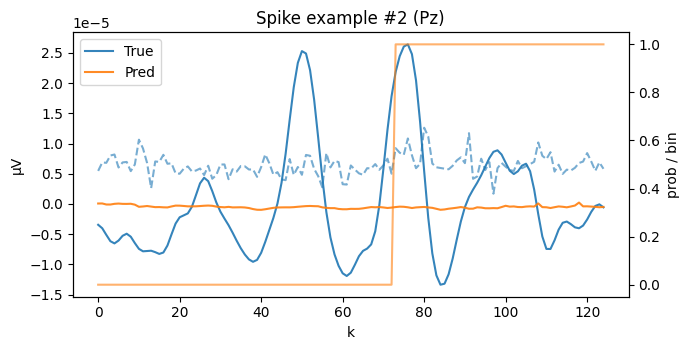

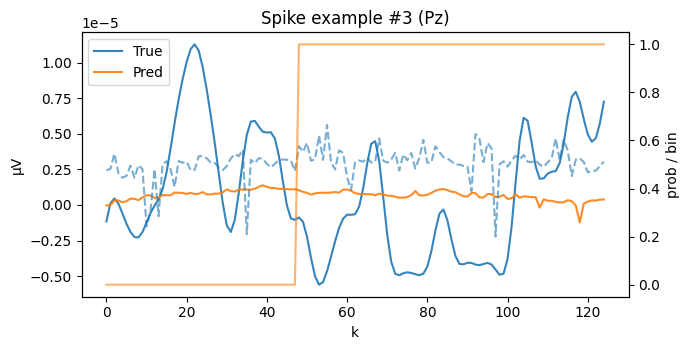

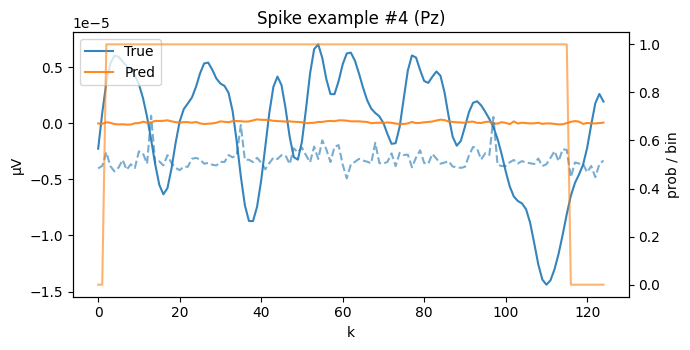

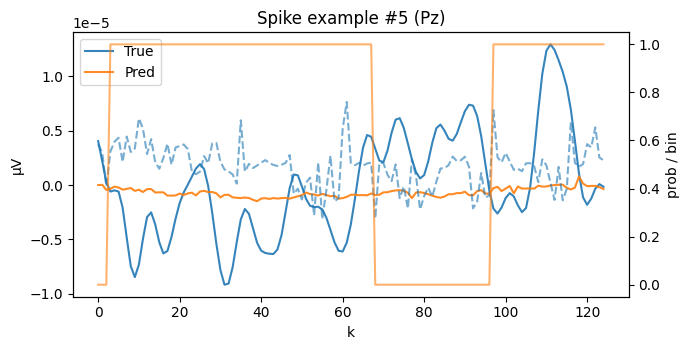

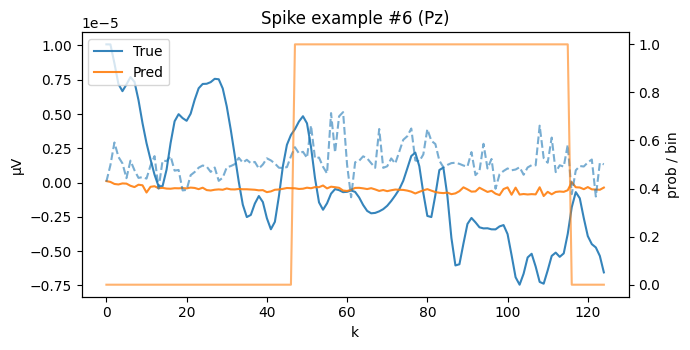

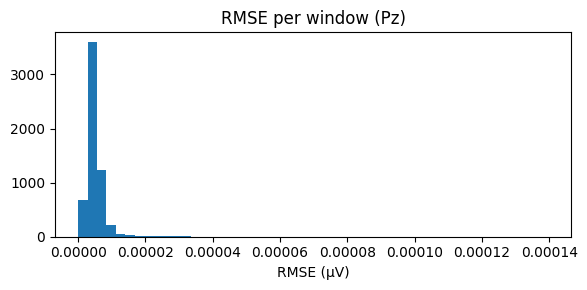

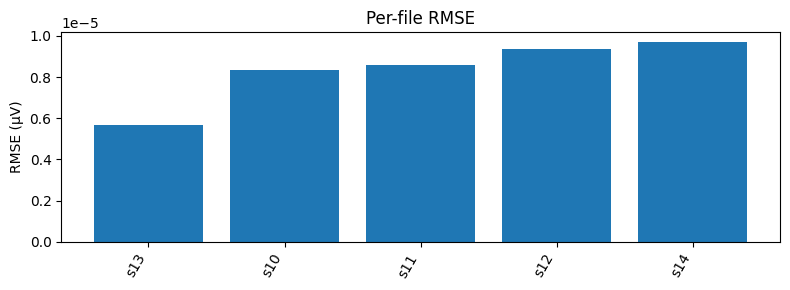

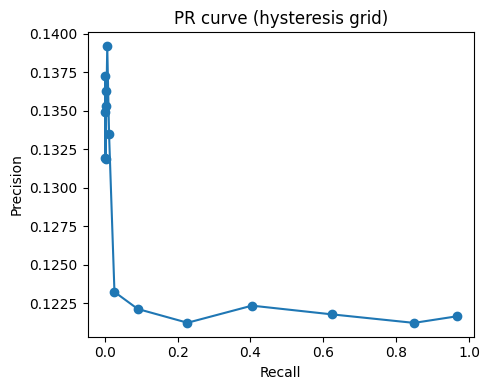

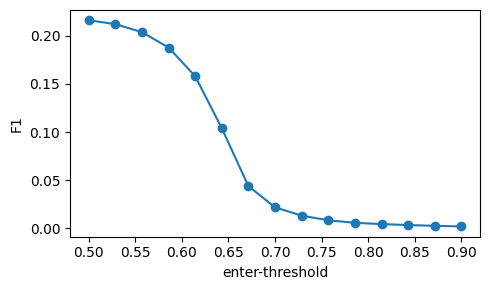

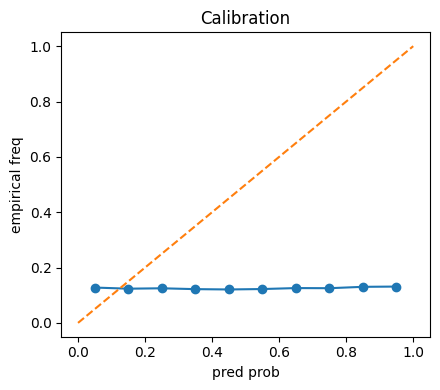

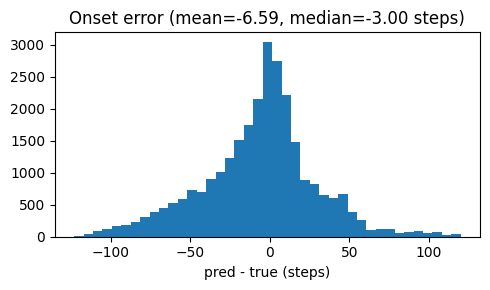

[saved] diagnostics → outputs_v3


In [89]:
# =============== v3.1 — подробные графики и метрики на тесте ===============
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from pathlib import Path

OUT = Path("./outputs_v3"); OUT.mkdir(parents=True, exist_ok=True)

def _stable_sigmoid(x):
    x = np.clip(x, -50, 50)
    return 1.0/(1.0+np.exp(-x))

@torch.no_grad()
def collect_test(model, loader):
    model.eval()
    yh, yt, lg, spk_all, fids = [], [], [], [], []
    for batch in loader:
        # совместимость с датасетом v3.1
        if len(batch) == 6:
            xb, yb_t, mb, sb, spk, idxs = batch
        else:
            xb, yb_t, mb, sb, spk = batch
        xb = xb.to(device, non_blocking=True)
        yb_t = yb_t.to(device, non_blocking=True)
        mb = mb.to(device); sb = sb.to(device)

        with autocast(device_type=("cuda" if device.type=="cuda" else "cpu"),
                      dtype=torch.float16 if device.type=="cuda" else torch.bfloat16,
                      enabled=use_amp):
            yhat_t, logits = model(xb)

        yh.append(tspace_to_original(yhat_t, mb, sb))   # (B,C,H) в µV
        yt.append(tspace_to_original(yb_t,   mb, sb))   # (B,C,H) в µV
        lg.append(logits.detach().cpu().numpy())        # (B,C,H)
        spk_all.append(spk.detach().cpu().numpy().astype(np.float32))

    yhat  = np.concatenate(yh, 0)
    ytrue = np.concatenate(yt, 0)
    logits= np.concatenate(lg, 0)
    spk   = np.concatenate(spk_all, 0)
    prob  = _stable_sigmoid(logits / max(1e-6, temp_cal))
    pred_bin = apply_hysteresis(prob, thr_enter, thr_exit)
    pred_bin = postprocess_events(pred_bin, min_len=5, refractory=22)

    np.save(OUT/"yhat_test.npy",  yhat)
    np.save(OUT/"ytrue_test.npy", ytrue)
    np.save(OUT/"logits_test.npy", logits)
    np.save(OUT/"prob_test.npy",   prob)
    np.save(OUT/"spikes_test.npy", spk)
    np.save(OUT/"predbin_test.npy", pred_bin)
    return yhat, ytrue, prob, spk, pred_bin

yhat, ytrue, prob, spk, pred_bin = collect_test(model, test_loader)

C, H = ytrue.shape[1], ytrue.shape[2]
ch2idx = {ch:i for i,ch in enumerate(channels_used)}
PZ = ch2idx.get("Pz", 0)

# ---- 1) Best/median/worst overlays по каналу Pz ----
rmse_per = np.sqrt(np.mean((yhat[:,PZ]-ytrue[:,PZ])**2, axis=1))
order = np.argsort(rmse_per)
best, median, worst = order[0], order[len(order)//2], order[-1]

def _plot_overlay(idx, title, fname):
    plt.figure(figsize=(7,2.8))
    plt.plot(ytrue[idx,PZ], label="True")
    plt.plot(yhat[idx,PZ],  label="Pred", alpha=0.85)
    plt.title(f"{title} (RMSE={rmse_per[idx]:.3e}) | ch=Pz")
    plt.xlabel("horizon k"); plt.ylabel("µV"); plt.legend(); plt.tight_layout()
    plt.savefig(OUT/fname, dpi=150); plt.show()

_plot_overlay(best,   "Best sample",   "case_best_overlay.png")
_plot_overlay(median, "Median sample", "case_median_overlay.png")
_plot_overlay(worst,  "Worst sample",  "case_worst_overlay.png")

# ---- 2) Примеры со всплесками: сигнал + prob + бинаризация ----
has_spike = np.where(spk.sum(axis=(1,2)) > 0)[0]
pick = has_spike[:6] if len(has_spike)>=6 else has_spike
for i, idx in enumerate(pick):
    plt.figure(figsize=(7,3.6))
    ax1 = plt.gca()
    ax1.plot(ytrue[idx,PZ], label="True", alpha=0.9)
    ax1.plot(yhat[idx,PZ],  label="Pred", alpha=0.9)
    ax1.set_ylabel("µV"); ax1.set_xlabel("k")
    ax1.legend(loc="upper left")
    ax2 = ax1.twinx()
    ax2.plot(prob[idx,PZ],  alpha=0.6, linestyle="--")
    ax2.plot(pred_bin[idx,PZ], alpha=0.6)
    ax2.set_ylabel("prob / bin")
    plt.title(f"Spike example #{i+1} (Pz)")
    plt.tight_layout(); plt.savefig(OUT/f"spike_ex_{i+1}.png", dpi=150); plt.show()

# ---- 3) Распределения ошибок ----
plt.figure(figsize=(6,3))
plt.hist(rmse_per, bins=50); plt.title("RMSE per window (Pz)"); plt.xlabel("RMSE (µV)"); plt.tight_layout()
plt.savefig(OUT/"hist_rmse_windows_pz.png", dpi=150); plt.show()

rmse_file = []
# возьмём id файла из ранее сохранённого массива processed_v3/file_ids.npy
file_ids_test = np.load("./processed_v3/file_ids.npy", allow_pickle=True)[-len(ytrue):]
for fid in np.unique(file_ids_test):
    m = (file_ids_test == fid)
    diff = yhat[m] - ytrue[m]
    rmse_file.append((str(fid), float(np.sqrt(np.mean(diff**2)))))
df_file = pd.DataFrame(rmse_file, columns=["file","RMSE_uV"]).sort_values("RMSE_uV")
df_file.to_csv(OUT/"per_file_rmse.csv", index=False)
plt.figure(figsize=(8,3))
plt.bar(df_file["file"], df_file["RMSE_uV"]); plt.xticks(rotation=60, ha="right")
plt.ylabel("RMSE (µV)"); plt.title("Per-file RMSE"); plt.tight_layout()
plt.savefig(OUT/"rmse_per_file.png", dpi=150); plt.show()

# ---- 4) PR-кривая по порогам гистерезиса ----
def f1_from_prob(prob, spk, enter, exit_):
    pb = apply_hysteresis(prob, enter, exit_)
    pb = postprocess_events(pb, min_len=5, refractory=25)
    tp = (pb*spk).sum(); fp = (pb*(1-spk)).sum(); fn = ((1-pb)*spk).sum()
    P = float(tp/(tp+fp+1e-12)); R = float(tp/(tp+fn+1e-12)); F1 = float(2*P*R/(P+R+1e-12))
    return P, R, F1

grid = np.linspace(0.5, 0.9, 15)
PR = []
for e in grid:
    P,R,F1 = f1_from_prob(prob, spk, enter=e, exit_=max(0.35, e-0.15))
    PR.append((e,P,R,F1))
df_pr = pd.DataFrame(PR, columns=["enter","P","R","F1"])
df_pr.to_csv(OUT/"pr_curve.csv", index=False)

plt.figure(figsize=(5,4))
plt.plot(df_pr["R"], df_pr["P"], marker="o")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR curve (hysteresis grid)")
plt.tight_layout(); plt.savefig(OUT/"pr_curve.png", dpi=150); plt.show()

plt.figure(figsize=(5,3))
plt.plot(df_pr["enter"], df_pr["F1"], marker="o"); plt.xlabel("enter-threshold"); plt.ylabel("F1")
plt.tight_layout(); plt.savefig(OUT/"f1_vs_enter.png", dpi=150); plt.show()

# ---- 5) Калибровка вероятностей (reliability) ----
p = prob.reshape(-1)
y = spk.reshape(-1)
bins = np.linspace(0,1,11)
ix = np.digitize(p, bins)-1
emp = [y[ix==i].mean() if np.any(ix==i) else np.nan for i in range(len(bins)-1)]
plt.figure(figsize=(4.5,4))
plt.plot([(bins[i]+bins[i+1])/2 for i in range(len(bins)-1)], emp, marker="o")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("pred prob"); plt.ylabel("empirical freq")
plt.title("Calibration"); plt.tight_layout(); plt.savefig(OUT/"calibration.png", dpi=150); plt.show()

# ---- 6) Ошибка начала события (onset) ----
def first_onset(v): 
    idx = np.where(v>0.5)[0]
    return None if len(idx)==0 else int(idx[0])
errs=[]
for b in range(pred_bin.shape[0]):
    for c in range(pred_bin.shape[1]):
        t = first_onset(spk[b,c]); p = first_onset(pred_bin[b,c])
        if t is not None and p is not None:
            errs.append(p - t)  # >0 — опоздали, <0 — предсказали заранее
if errs:
    plt.figure(figsize=(5,3)); plt.hist(errs, bins=41)
    plt.title(f"Onset error (mean={np.mean(errs):.2f}, median={np.median(errs):.2f} steps)")
    plt.xlabel("pred - true (steps)"); plt.tight_layout()
    plt.savefig(OUT/"onset_error_hist.png", dpi=150); plt.show()
print(f"[saved] diagnostics → {OUT}")
